# Cross-matching entre 2 tables 

Il faut remplacer le nom des variables par les tables qu'on souhaite comparer.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
import math
import scipy
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table
from astropy.cosmology import Planck13
import pickle
import os
import random
from collections import Counter
from scipy.spatial import cKDTree

In [12]:
from gem_astmatch_modified import match_celestial_objects_list_deg,match_celestial_objects,create_skycoord_from_fits,do_celest_match_fits   

# Variables à personaliser dans chaque cas

Il reste à modifier dans chaque cas les quantités d'intérêts à afficher dans la partie "Visualisation résultats associations".

In [13]:
# On précise le chemin menant à chacun des catalogues pour ensuite les importer
path_1 = '../SCUSS_DESI/SCUSS_Gao_2020.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen
name_1 = 'SCUSS_Gao_2020'

path_2 = '../SCUSS_DESI/DESI_Legacy_Wen_2024.fit'
name_2 = 'Wen_2024_DESI_Legacy'


# On ajoute une variable binaire "NEED_TO_VIZUALISE" pour n'afficher les graphes que quand c'est utile (c'est à dire quand on cherche à définir les zones de footprints communes)
NEED_TO_VIZUALISE = True


# Tolérance angulaire en degrés pour la sélection de la footprint : on prend 2 degrés (←→ 120' ←→ 7200'')
tol_ang_selection = 2 


#Paramètres asssociation

skyresol_deg = 5 # découpage du ciel en degrés, pour éviter de comparer un objet à tout les autres dans le ciel, mais seulement à ceux dans la même zone (TO DO : penser à implémenter cet aspect concrètement) 
tol_ang_fixe_arcmin = 15.0 # tolérance angulaire fixe en arcminutes → UTILITé ?
min_tol_ang_arcmin = 0.5 # tolerance angulaire plancher en arcminutes (CHOI1 → eROSITA a une tolérance de 30 arcsec)
rayon_cluster_MPC = 1 # rayon du cluster (en MPC) → influence le calcule de la tolérance angulaire en fonction du redshift
delta_z = 0.010 # largeur du bin de z  (CHOIX → DESI Legacy Imaging Surveys : incertitude de 0.010 sur le z photométrique : p.14 Wen and Han 2024)
cosmo = Planck13 # modèle cosmo utilisé : FlatLambdaCDM(name='Planck13', H0=<Quantity 67.77 km / (Mpc s)>, Om0=0.30712, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.048252)

name_indexes_crossed = 'SELECTED_0_5_arcmin__1_MPC__0_010_z.pkl' # x1 arcmin' as the minimum angular tolerance, 'x2 Mpc' as the typical cluster radius, and 'x3_z' as the redshift bin 

#Indique si on va réaliser le calcul de l'association 1→2 ou 2→1 (True) ou si on se contente de lire les indices d'associtaion précedemment calculés (False):
RUN_1_2 = False
RUN_2_1 = False


# Noms des colonnes de redshift dans les tables (on en chaque fois deux au cas où la table différencie les redshifts photométriques et spectroscopiques)
#table 1
name_z_1_a = 'zsp'  
name_z_1_b = 'zph'  
#table 2
name_z_2_a = 'zCl'
name_z_2_b = 0

# Dossier pour les indices croisés
folder_1_2_indexes = f'../SCUSS_DESI/indexes_crossed/{name_1}_TO_{name_2}/' 
os.makedirs(folder_1_2_indexes, exist_ok=True)
# Dossier de sortie pour les indices croisés 2 → 1
folder_2_1_indexes = f'../SCUSS_DESI/indexes_crossed/{name_2}_TO_{name_1}/' 
os.makedirs(folder_2_1_indexes, exist_ok=True)

# Dossier où stocker les plots
folder_plots = f"../SCUSS_DESI/figures/{name_indexes_crossed}/"
os.makedirs(folder_plots, exist_ok=True)


# Import catalogues

Fonction pour passer de .fit à un dataframe (REMARQUE : Le programme ne semble pas fonctionner pour certains fits binary → dans le doute télécharger des fits ascii) : 

In [14]:
# Transforme certaines extensions d'un fichier FITS en un fichier FITS ASCII
def fits_binary_to_fits_ascii_list(fits_file, liste_indexes, name_list):  # liste_indexes indique les extensions du fits à lire ; name_list correspond aux noms des fichiers de sortie
    for x, x_name in zip(liste_indexes, name_list):  # Use zip to iterate over both lists simultaneously
        with fits.open(fits_file) as hdul:
            data = hdul[x].data
            data_table = Table(data)  # Convertit le tableau binaire en un tableau astropy
            data_table.write(x_name, overwrite=True, format='ascii')  # Écrit le tableau dans un fichier FITS ASCII

#Transforme un FITS ascii en un DataFrame pandas
def ascii_to_dataframe(ascii_file, delimiter=' '):
    data_df = pd.read_csv(ascii_file, delimiter=delimiter)
    return data_df

# Transfome la première extension d'un fichier FITS en un DataFrame pandas
def fits_to_dataframe(fits_file):
    with fits.open(fits_file) as hdul:
        data = hdul[1].data 
        data_df = pd.DataFrame(data)
    return data_df




# Transforme certaines extensions d'un fichier FITS en un DataFrame pandas(→ pour que ça fonctionne, il faut un fits ascii et pas un fits binaire)
def fits_to_dataframe_list(fits_file, liste_indexes):  # liste_indexes indique les extensions du fits à lire
    df_list = []  # Initialize the list outside the loop
    with fits.open(fits_file) as hdul:
        for x in liste_indexes:
            data = hdul[x].data  # Select the data in the xth extension
            df_list.append(pd.DataFrame(data))
            print(df_list)
    return df_list  # Return the entire list of DataFrames

#def fits_binary_to_fits_ascii(fits_file):

In [15]:
#On importe les catalogues en tant que DataFrame pandas

table_1 = fits_to_dataframe(path_1)

table_2 = fits_to_dataframe(path_2)

In [16]:
table_2

,_RAJ2000,_DEJ2000,ID,n_Name,Name,RAJ2000,DEJ2000,zCl,f_zCl,zmag,...,logMs,r500,lam500,M500,Ngal,Gamma,e_Gamma,imag_,Cat,recno
0,0.00046,-37.47628,1,,J000000.1-372835,0.00046,-37.47628,0.1364,0,15.377,...,11.49,0.766,25.79,1.17,14,0.0,0.0,1,WHY18,1
1,0.00135,-56.58835,2,WH-,J000000.3-563518,0.00135,-56.58835,0.1957,0,15.712,...,11.70,0.625,23.24,1.06,7,0.0,0.0,1,,2
2,0.00172,-39.32369,3,,J000000.4-391925,0.00172,-39.32369,0.3580,0,17.713,...,11.41,0.526,15.90,0.73,7,0.0,0.0,1,Y21,3
3,0.00201,2.31980,4,,J000000.5+021911,0.00201,2.31980,0.4282,1,18.043,...,11.55,0.612,23.40,1.07,13,0.0,0.0,1,redMaPPer,4
4,0.00260,-59.01297,5,WH-,J000000.6-590047,0.00260,-59.01297,0.1380,0,14.993,...,11.69,0.606,15.71,0.73,7,0.0,0.0,1,,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581174,359.99667,4.99211,1581175,WH-,J235959.2+045932,359.99667,4.99211,0.5948,0,19.184,...,11.37,0.420,10.99,0.51,6,0.0,0.0,2,,1581175
1581175,359.99680,21.78514,1581176,,J235959.2+214707,359.99680,21.78514,0.4050,1,17.259,...,11.78,0.658,31.73,1.43,9,0.0,0.0,2,WHL,1581176
1581176,359.99817,10.04951,1581177,,J235959.6+100258,359.99817,10.04951,0.7919,0,18.904,...,11.88,0.621,33.23,1.50,8,0.0,0.0,2,CFSFDP,1581177
1581177,359.99847,-6.34469,1581178,WH-,J235959.6-062041,359.99847,-6.34469,1.0333,0,20.952,...,11.18,0.439,13.12,0.61,6,0.0,0.0,2,,1581178


In [17]:
table_1

,_RAJ2000,_DEJ2000,Name,RAJ2000,DEJ2000,zph,zsp,zphmedian,N1Mpc,L1Mpc,Richness,M500,recno
0,0.00035,13.02347,0,0.00035,13.02347,0.3769,0.00000,0.38710,24,7.00224,22.90440,1.26,1
1,0.00635,2.95542,1,0.00635,2.95542,0.4571,0.42290,0.43890,17,6.56276,23.13604,1.27,2
2,0.00958,5.28826,2,0.00958,5.28826,0.1734,0.16936,0.17750,58,14.09044,35.83500,2.04,3
3,0.01474,31.78564,3,0.01474,31.78564,0.0824,0.00000,0.10490,64,12.95997,25.62747,1.42,4
4,0.01476,8.94881,4,0.01476,8.94881,0.2609,0.00000,0.27620,26,8.83946,24.11363,1.33,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19605,359.97270,13.33689,19605,359.97270,13.33689,0.2360,0.24498,0.23050,24,6.31375,14.90396,0.79,19606
19606,359.98382,3.48642,19606,359.98382,3.48642,0.5132,0.00000,0.51320,20,8.83291,40.95954,2.35,19607
19607,359.98503,-3.43589,19607,359.98503,-3.43589,0.3251,0.00000,0.32065,26,8.59997,26.87073,1.49,19608
19608,359.98757,8.56171,19608,359.98757,8.56171,0.3556,0.00000,0.37079,14,3.79424,9.74870,0.50,19609


In [18]:
# On calcule les coordonnées galactiques

'''# objets table 1 
raj2000_1_list = table_1['RAJ2000'].tolist()
dej2000_1_list = table_1['DEJ2000'].tolist()
j2000_coords_1 = SkyCoord(raj2000_1_list, dej2000_1_list, unit=(u.degree, u.degree), frame='icrs')
galactic_coords_1 = j2000_coords_1.galactic # conversion J2000 -> galactique

# objets table 2
raj2000_2_list = table_2['RAJ2000'].tolist()
dej2000_2_list = table_2['DEJ2000'].tolist()
j2000_coords_2 = SkyCoord(raj2000_2_list, dej2000_2_list, unit=(u.degree, u.degree), frame='icrs')
galactic_coords_2 = j2000_coords_2.galactic # conversion J2000 -> galactique'''


output_folder = "../SCUSS_DESI/"  


'''# Save 'galactic_coords_x'
with open(os.path.join(output_folder, f'galactic_coords_{name_1}.pkl'), 'wb') as file:
    pickle.dump(galactic_coords_1, file)

# Save 'galactic_coords_2'
with open(os.path.join(output_folder, f'galactic_coords_{name_2}.pkl'), 'wb') as file:
    pickle.dump(galactic_coords_2, file)'''

"# Save 'galactic_coords_x'\nwith open(os.path.join(output_folder, f'galactic_coords_{name_1}.pkl'), 'wb') as file:\n    pickle.dump(galactic_coords_1, file)\n\n# Save 'galactic_coords_2'\nwith open(os.path.join(output_folder, f'galactic_coords_{name_2}.pkl'), 'wb') as file:\n    pickle.dump(galactic_coords_2, file)"

In [19]:
# On récupère les coordonnées galactiques et on les ajoute aux tables

with open(os.path.join(output_folder, f'galactic_coords_{name_1}.pkl'), 'rb') as file:
    galactic_coords_1 = pickle.load(file)
with open(os.path.join(output_folder, f'galactic_coords_{name_2}.pkl'), 'rb') as file:
    galactic_coords_2 = pickle.load(file)

table_1['glon'] = galactic_coords_1.l.deg ; table_1['glat'] = galactic_coords_1.b.deg
table_1 = table_1[['glat'] + [col for col in table_1.columns if col != 'glat']]
table_1 = table_1[['glon'] + [col for col in table_1.columns if col != 'glon']]

table_2['glon'] = galactic_coords_2.l.deg ; table_2['glat'] = galactic_coords_2.b.deg
table_2 = table_2[['glat'] + [col for col in table_2.columns if col != 'glat']]
table_2 = table_2[['glon'] + [col for col in table_2.columns if col != 'glon']]



In [20]:
table_1

,glon,glat,_RAJ2000,_DEJ2000,Name,RAJ2000,DEJ2000,zph,zsp,zphmedian,N1Mpc,L1Mpc,Richness,M500,recno
0,104.041987,-47.952774,0.00035,13.02347,0,0.00035,13.02347,0.3769,0.00000,0.38710,24,7.00224,22.90440,1.26,1
1,98.536862,-57.460835,0.00635,2.95542,1,0.00635,2.95542,0.4571,0.42290,0.43890,17,6.56276,23.13604,1.27,2
2,100.049582,-55.283444,0.00958,5.28826,2,0.00958,5.28826,0.1734,0.16936,0.17750,58,14.09044,35.83500,2.04,3
3,110.350582,-29.827790,0.01474,31.78564,3,0.01474,31.78564,0.0824,0.00000,0.10490,64,12.95997,25.62747,1.42,4
4,102.115166,-51.834197,0.01476,8.94881,4,0.01476,8.94881,0.2609,0.00000,0.27620,26,8.83946,24.11363,1.33,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19605,104.141421,-47.645372,359.97270,13.33689,19605,359.97270,13.33689,0.2360,0.24498,0.23050,24,6.31375,14.90396,0.79,19606
19606,98.856970,-56.958426,359.98382,3.48642,19606,359.98382,3.48642,0.5132,0.00000,0.51320,20,8.83291,40.95954,2.35,19607
19607,93.260257,-63.301439,359.98503,-3.43589,19607,359.98503,-3.43589,0.3251,0.00000,0.32065,26,8.59997,26.87073,1.49,19608
19608,101.871431,-52.192059,359.98757,8.56171,19608,359.98757,8.56171,0.3556,0.00000,0.37079,14,3.79424,9.74870,0.50,19609


In [21]:
table_2

,glon,glat,_RAJ2000,_DEJ2000,ID,n_Name,Name,RAJ2000,DEJ2000,zCl,...,logMs,r500,lam500,M500,Ngal,Gamma,e_Gamma,imag_,Cat,recno
0,346.037516,-75.021144,0.00046,-37.47628,1,,J000000.1-372835,0.00046,-37.47628,0.1364,...,11.49,0.766,25.79,1.17,14,0.0,0.0,1,WHY18,1
1,316.752759,-59.138458,0.00135,-56.58835,2,WH-,J000000.3-563518,0.00135,-56.58835,0.1957,...,11.70,0.625,23.24,1.06,7,0.0,0.0,1,,2
2,340.962781,-73.774528,0.00172,-39.32369,3,,J000000.4-391925,0.00172,-39.32369,0.3580,...,11.41,0.526,15.90,0.73,7,0.0,0.0,1,Y21,3
3,98.087140,-58.049446,0.00201,2.31980,4,,J000000.5+021911,0.00201,2.31980,0.4282,...,11.55,0.612,23.40,1.07,13,0.0,0.0,1,redMaPPer,4
4,315.038146,-56.890161,0.00260,-59.01297,5,WH-,J000000.6-590047,0.00260,-59.01297,0.1380,...,11.69,0.606,15.71,0.73,7,0.0,0.0,1,,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581174,99.846285,-55.556496,359.99667,4.99211,1581175,WH-,J235959.2+045932,359.99667,4.99211,0.5948,...,11.37,0.420,10.99,0.51,6,0.0,0.0,2,,1581175
1581175,107.386200,-39.528434,359.99680,21.78514,1581176,,J235959.2+214707,359.99680,21.78514,0.4050,...,11.78,0.658,31.73,1.43,9,0.0,0.0,2,WHL,1581176
1581176,102.648089,-50.784985,359.99817,10.04951,1581177,,J235959.6+100258,359.99817,10.04951,0.7919,...,11.88,0.621,33.23,1.50,8,0.0,0.0,2,CFSFDP,1581177
1581177,90.146970,-65.886375,359.99847,-6.34469,1581178,WH-,J235959.6-062041,359.99847,-6.34469,1.0333,...,11.18,0.439,13.12,0.61,6,0.0,0.0,2,,1581178


# Visualisation zones communes et sélection

On va notamment chercher à quantifier l'efficacité de l'association, c'est à dire le rapport d'amas 1 associés sur le rapport d'amas 1 total : cependant pour que cela ait un intérêt, il nous faut auparavant sélectionner les objets situés dans les footprint communes aux objets 1 et 2.

## Visualisation (en coordonnées galactiques)

In [22]:
#Transformation des coordonnées galactiques en listes

glon_1 = table_1['glon'].tolist() ; glat_1 = table_1['glat'].tolist()

glon_2 = table_2['glon'].tolist() ; glat_2 = table_2['glat'].tolist()


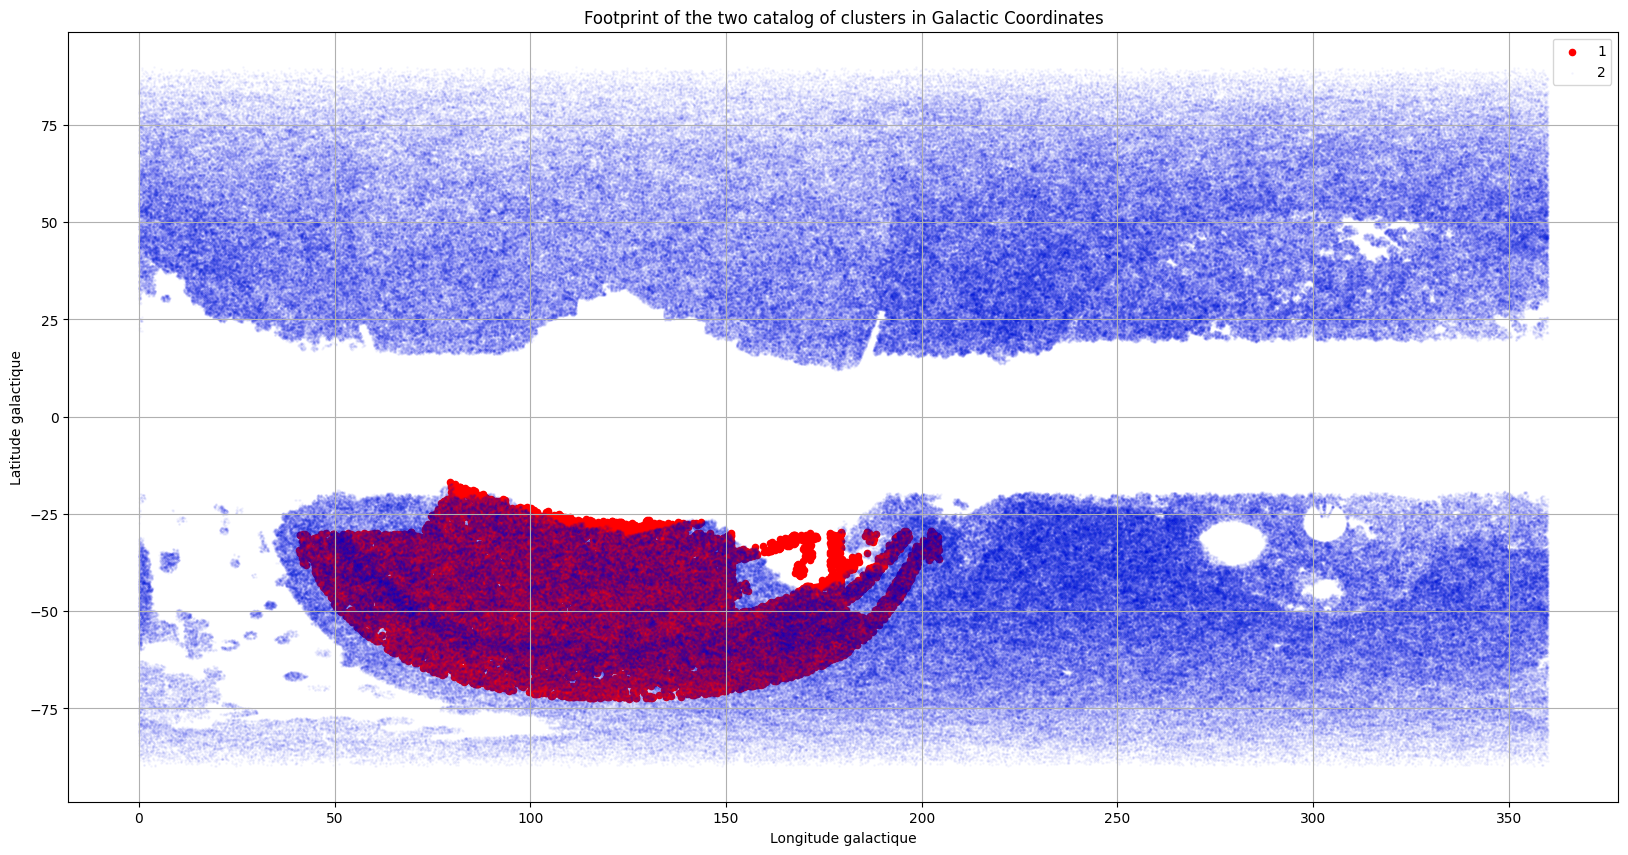

In [23]:
if NEED_TO_VIZUALISE:

    fig = plt.figure(figsize=(20, 10))
    ax_projection_1_all = plt.subplot(111)
    ax_projection_2_all = plt.subplot(111)

    ax_projection_1_all.scatter(glon_1, glat_1, s=20,facecolors='red',label='1') 
    ax_projection_1_all.grid(True)
    ax_projection_1_all.set_xlabel("Longitude galactique")
    ax_projection_1_all.set_ylabel("Latitude galactique")

    ax_projection_2_all.scatter(glon_2, glat_2,s=1,edgecolors='blue',alpha=0.03,label='2') 
    ax_projection_2_all.grid(True)
    ax_projection_2_all.set_xlabel("Longitude galactique")
    ax_projection_2_all.set_ylabel("Latitude galactique")

   


    plt.title(f"Footprint of the two catalog of clusters in Galactic Coordinates")
    plt.legend()

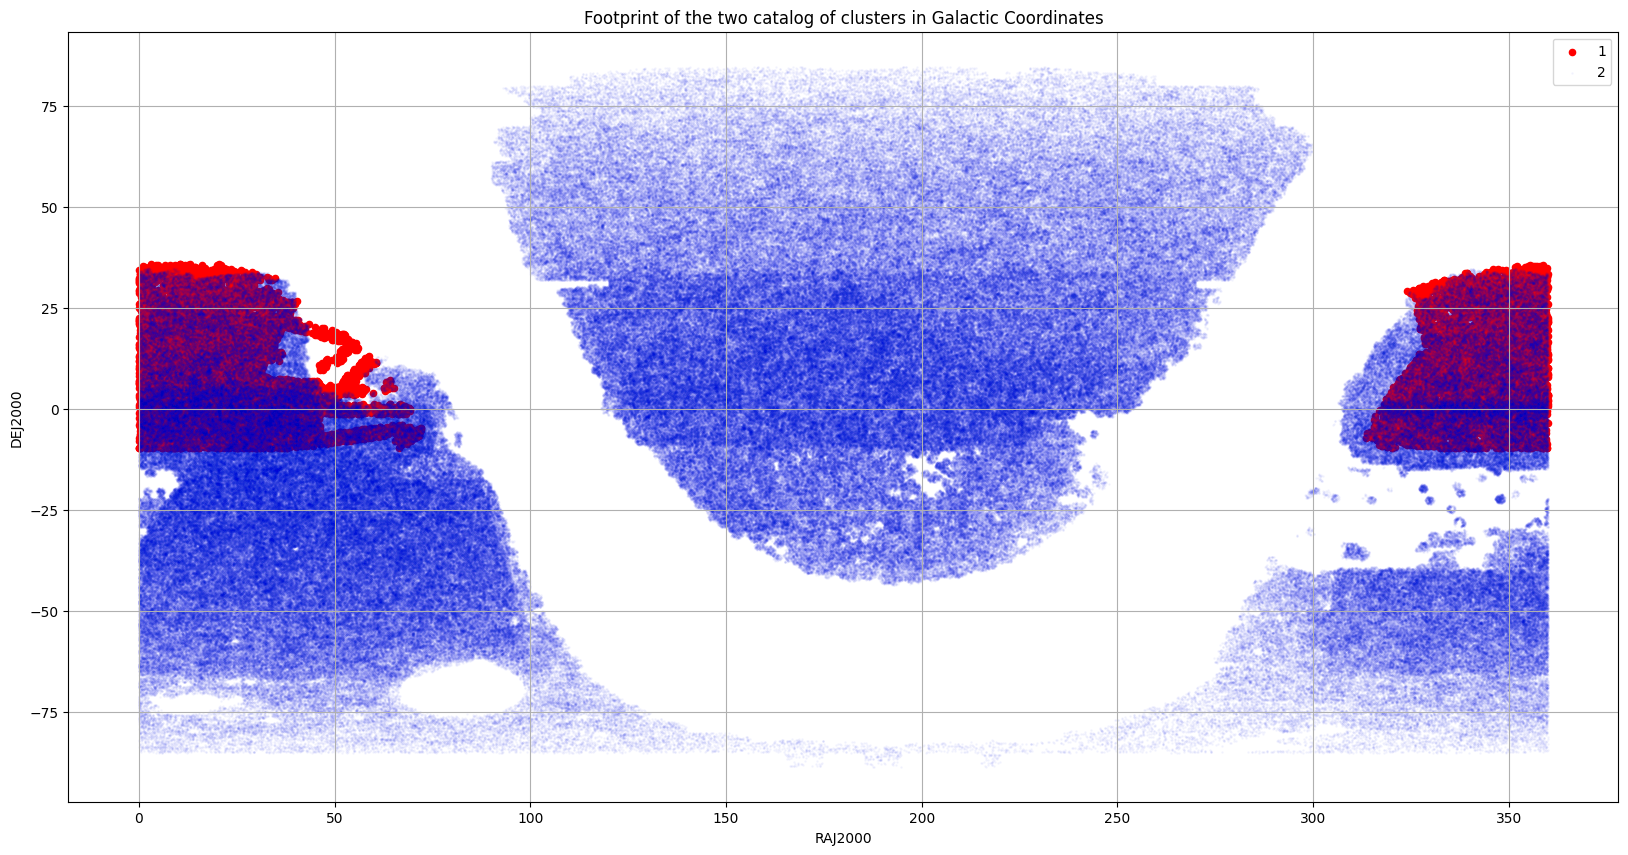

In [24]:
if NEED_TO_VIZUALISE:
    # On affiche la zone sélectionnée en coordonnées J2000 

    raj2000_1 = table_1['RAJ2000'].tolist() ; dej2000_1 = table_1['DEJ2000'].tolist()
    raj2000_2 = table_2['RAJ2000'].tolist() ; dej2000_2 = table_2['DEJ2000'].tolist()

    plt.figure(figsize=(20, 10))
    ax_projection_1 = plt.subplot(111)
    ax_projection_2 = plt.subplot(111)
    ax_projection_1_all = plt.subplot(111)
    ax_projection_2_all = plt.subplot(111)


    ax_projection_1_all.scatter(raj2000_1, dej2000_1, s=20,facecolors='red',label='1') 
    ax_projection_1_all.grid(True)
    ax_projection_1_all.set_xlabel("RAJ2000")
    ax_projection_1_all.set_ylabel("DEJ2000") 

    ax_projection_2_all.scatter(raj2000_2, dej2000_2,s=1,edgecolors='blue',alpha=0.03,label='2') 
    ax_projection_2_all.grid(True)
    ax_projection_2_all.set_xlabel("RAJ2000")
    ax_projection_2_all.set_ylabel("DEJ2000")


    plt.title(f"Footprint of the two catalog of clusters in Galactic Coordinates")
    plt.legend()

## Sélection avec KDTree → POURRAIT REMPLACER MA METHODE D'ASSOCIATION (à comparer) ???

In [25]:
coords_1_galactic = np.column_stack((table_1['glon'], table_1['glat']))
coords_2_galactic = np.column_stack((table_2['glon'], table_2['glat']))



In [26]:
# Association d'éléments 1 → 2 

tree_2 = cKDTree(coords_2_galactic)

idx_1_in_2 = tree_2.query_ball_point(coords_1_galactic, r = tol_ang_selection)  # idx_1_in_2 → list of lists: each sublist contains the indices of matching points in tree_2 for the corresponding point in coords_1
mask_common_1 = np.array([len(match) > 0 for match in idx_1_in_2]) #indique les points de la table 1 qui ont au moins un point asscié dans la table 2 

table_1_common = table_1[mask_common_1]

In [27]:
# Dans l'autre sens : 2 → 1

tree_1 = cKDTree(coords_1_galactic)

idx_2_in_1 = tree_1.query_ball_point(coords_2_galactic, r = tol_ang_selection) # idx_2_in_1 → list of lists: each sublist contains the indices of matching points in tree_1 for the corresponding point in coords_2
mask_common_2 = np.array([len(match) > 0 for match in idx_2_in_1]) #indique les points de la table 2 qui ont au moins un point asscié dans la table 1

table_2_common = table_2[mask_common_2]

In [28]:
mask_common_2

array([False, False, False, ...,  True,  True,  True], shape=(1581179,))

In [29]:
glon_1_common = table_1_common['glon'].tolist() ; glat_1_common = table_1_common['glat'].tolist()

glon_2_common = table_2_common['glon'].tolist() ; glat_2_common = table_2_common['glat'].tolist()


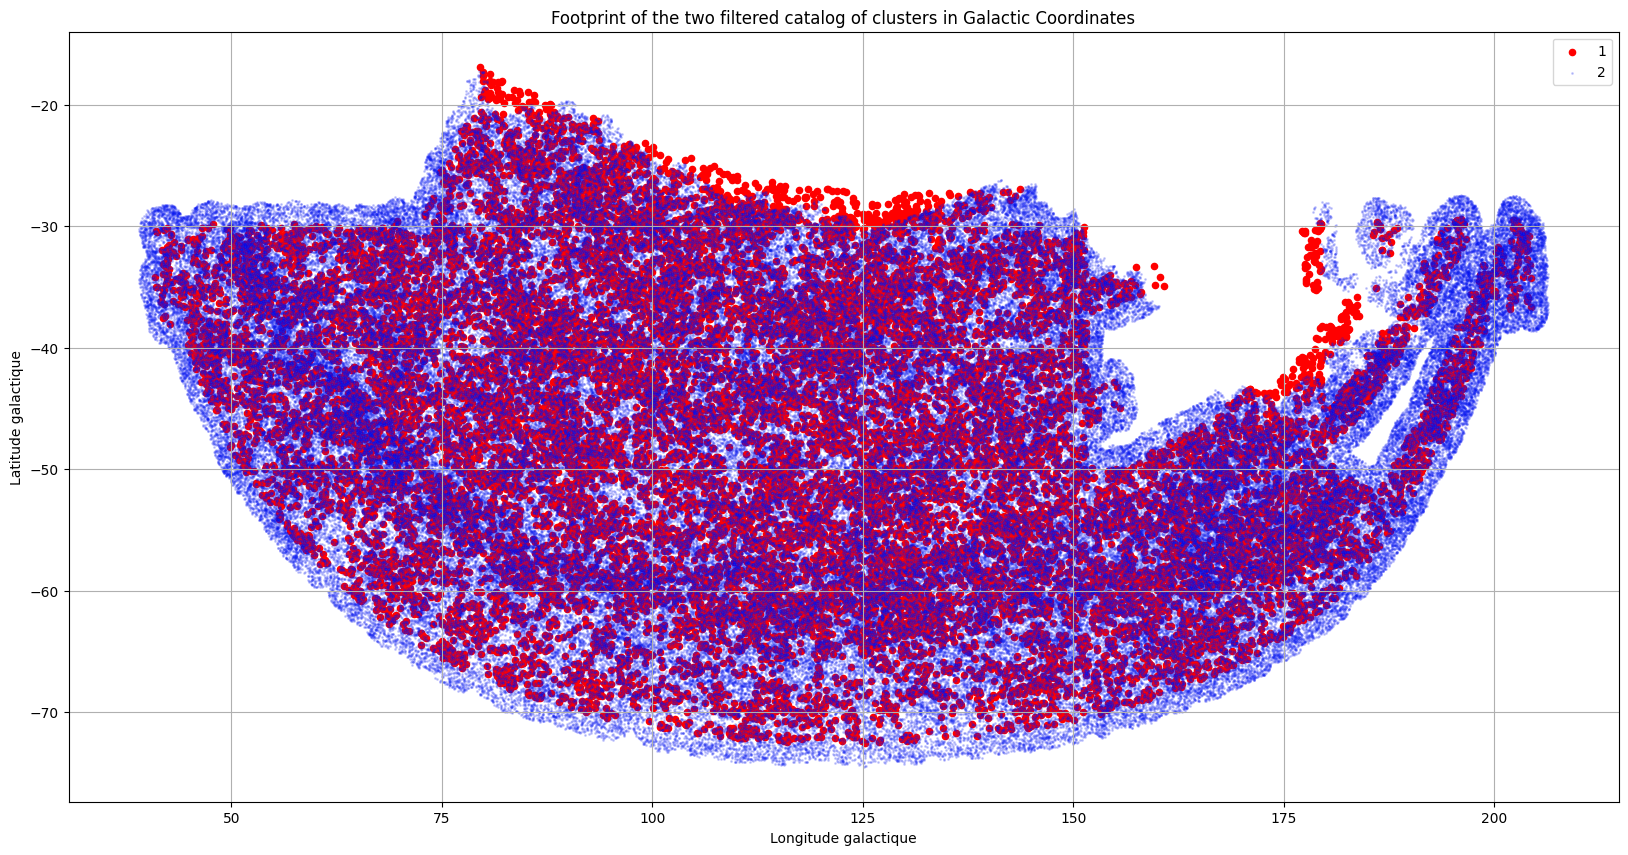

In [30]:
if NEED_TO_VIZUALISE:

    fig = plt.figure(figsize=(20, 10))
    ax_projection_1_common = plt.subplot(111)
    ax_projection_2_common = plt.subplot(111)

    ax_projection_1_common.scatter(glon_1_common, glat_1_common, s=20,facecolors='red',label='1') 
    ax_projection_1_common.grid(True)
    ax_projection_1_common.set_xlabel("Longitude galactique")
    ax_projection_1_common.set_ylabel("Latitude galactique")


    ax_projection_2_common.scatter(glon_2_common, glat_2_common,s=1,edgecolors='blue',alpha=0.2,label='2') 
    ax_projection_2_common.grid(True)
    ax_projection_2_common.set_xlabel("Longitude galactique")
    ax_projection_2_common.set_ylabel("Latitude galactique")

    plt.title(f"Footprint of the two filtered catalog of clusters in Galactic Coordinates")
    plt.legend()

# Association

Dans la suite il y aura deux types d'associations : une association 1→2 et une association 2→1. Elles différent par le point de départ de l'association : dans le cas 1→2, on prend un objet 1, on trace autour de ce point un cylindre de longueur delta_z et de rayon la tolérance angulaire, et on récupère tous les objets 2 à l'intérieur pour définir les associations : c'est l'inverse dans le 2→1. \
Pour l'association "1 → 2" : "table_1_crossed_3D" indique les proriétés des objets 1 centraux qui ont obtenu au moins une association dans 2, et "table_2_associated_3D" représente ces objets.
C'est l'inverse pour l'association "2 → 1" avec "table_2_crossed_3D" et "table_1_crossed_3D".\
Il s'avèrerait que ces méthodes ne sont pas tout à fait équivalentes (à vérifier avec la dernière cellule de cette partie qui détermine le pourcentage de différence entre le nombre des deux types d'associations).

UPDATE 06/06 : On a déjà associé les éléments des deux tables précedemment, en fonction de leur distance angulaire (avec la méthode "query_ball_point" sur les objets "tree"), mais cela ne prend pas en compte l'évolution de la tolérance angulaire en fonction du redshift qu'on va donc implémenter ici.

## Détermination tolérance angulaire en fonction du redshift (inspiré du code SOPHYA de Reza)

In [31]:
# A MODIFIER POUR CHAQUE CATALOGUES !!!

# Colonne z : chaque table possède des noms de colonnes différents pour le redshift, on récupère ici à chaque fois les redshifts les plus précis pour chaque objet et on en fait une colonne nommée 'z'

z1_list = []
for idx, row in table_1.iterrows():
    if row[f'{name_z_1_a}'] == 0:
        z1_list.append(row[f'{name_z_1_b}'])
    else:
        z1_list.append(row[f'{name_z_1_a}'])
table_1['z'] = z1_list

z2_list = table_2[f'{name_z_2_a}'].tolist()  
table_2['z'] = z2_list


In [32]:
def find_tol_ang_wrt_z(cosmo,z,rayon_cluster_MPC,min_tol_ang_arcmin,skyresol_deg):
    
    tol_ang_variable = rayon_cluster_MPC/cosmo.angular_diameter_distance(z).value # cosmo.angular_diameter_distance est en MPC donc tol_ang_variable est en radian
    tol_ang = math.radians((min_tol_ang_arcmin/60)) + tol_ang_variable   # Sûr ???

    skyresol_rad = math.radians(skyresol_deg)

    if tol_ang > skyresol_rad:
        tol_ang = skyresol_rad

    tol_ang = math.degrees(tol_ang) *3600 # Convertit en secondes d'arc
    return tol_ang 

# Détermination du nombre de bins de redshift
nb_bin_z_1 = round(table_1['z'].max()/delta_z,0) ; nb_bin_z_2 = round(table_2['z'].max()/delta_z,0)
nb_bin_z = int(max(nb_bin_z_1, nb_bin_z_2))
print(f" On va considérer {nb_bin_z} bins de redshift ({delta_z} de large)")

tol_ang_list = [] # On va y placer les tolérances angulaires pour chaque bin de redshift : on prend à chaque fois la valeur maximale du bin de redshift afin d'obtenir la tolérance angulaire la plus contraignante
for i in range(nb_bin_z):
    tol_ang_current = find_tol_ang_wrt_z(cosmo,(i+1)*delta_z,rayon_cluster_MPC,min_tol_ang_arcmin,skyresol_deg)
    tol_ang_list.append(tol_ang_current)
print(f"tol_ang_list : {tol_ang_list}")

# On découpe les tables en fonction des bins de redshift
table_1_list_bins = []
table_2_list_bins = [] 

def cut_table_bins_z(table,name_z,nb_bins):
    table_bins_list = []
    for i in range(nb_bins):
        z_min = i*delta_z
        z_max = (i+1)*delta_z
        table_bins = table[(table[name_z] >= z_min) & (table[name_z] <= z_max)]
        table_bins_list.append(table_bins)
    return table_bins_list 

table_1_list_bins = cut_table_bins_z(table_1,'z',nb_bin_z) # On découpe la table 1 en fonction des bins de redshift
table_2_list_bins = cut_table_bins_z(table_2,'z',nb_bin_z) # idem mais pour la table 2


 On va considérer 173 bins de redshift (0.01 de large)
tol_ang_list : [4750.32359081026, 2419.105693107137, 1642.1377023396024, 1253.732684176972, 1020.7532429192147, 865.486905993414, 754.6283217444411, 671.5248088872112, 606.9248729946745, 555.2776130963683, 513.0506337715783, 477.88900119844817, 448.16237333648706, 422.70621717565655, 400.66653908752966, 381.40284129626724, 364.42532900821664, 349.3530484994732, 335.88524475575736, 323.7813118212253, 312.84647161982815, 302.9213585533464, 293.87432116139854, 285.59564836695625, 277.9931814233724, 270.98893848938906, 264.5164892988984, 258.5188924017257, 252.94705918238992, 247.7584450752764, 242.9159940931266, 238.38728125652509, 234.14381094535491, 230.16043907061234, 226.41489430248384, 222.88737909372261, 219.56023540189491, 216.41766319226377, 213.44548224784475, 210.630929707861, 207.962487234614, 205.4297328706844, 203.02321356709663, 200.73433509387235, 198.55526662903551, 196.4788577923825, 194.49856627053387, 192.6083944886

## Association 1 → 2

### Calcul des indices

In [33]:
# On commence par créer des listes de coordonnées (RAJ2000,DEJ2000) en récupérant les colonnes correspondantes sur les tables

liste_indexes_1 = [] # listes des indexes dans cahque bin, pour pouvoir réaliser l'association par la suite (en effet, le découpage en bin de redshift a mélangé les indices dans table_1_list_bins)
liste_coords_1 = [] # Liste de coordonnées (RAJ2000,DEJ2000) pour chaque bin de redshift
for x in table_1_list_bins:
    liste_indexes_1_bin = []
    liste_coords_1_bin = []
    for index,row in x.iterrows():
        liste_indexes_1_bin.append(index) ; liste_coords_1_bin.append((row['RAJ2000'],row['DEJ2000']))
    liste_indexes_1.append(liste_indexes_1_bin) ; liste_coords_1.append(liste_coords_1_bin)

liste_coords_2 = []
for index,row in table_2.iterrows():
    coord = (row['RAJ2000'],row['DEJ2000'])
    liste_coords_2.append(coord)


In [34]:
# TO DO ; trouver un moyen d'accélérer le calcul ! (voir cross_matching_1_2_tentative_accel_calcul.ipynb)

print(name_indexes_crossed) #pour rappeler quels paramètres ont été utilisés

if RUN_1_2 :
    indices_crossed = [] 
    for i in range(nb_bin_z):
        indices_crossed_current = match_celestial_objects_list_deg(liste_coords_1[i],liste_coords_2,tol_ang_list[i])
        indices_crossed.append(indices_crossed_current) 

    with open(os.path.join(folder_1_2_indexes, name_indexes_crossed), 'wb') as file:
        pickle.dump(indices_crossed, file)

SELECTED_0_5_arcmin__1_MPC__0_010_z.pkl


In [9]:
with open(os.path.join(folder_1_2_indexes, name_indexes_crossed), 'rb') as file:
    indices_crossed = pickle.load(file)

In [35]:
# Ici, on récupères les indices des objets 1, conservés dans liste_indexes_1, pour remplacer ceux obtenus avec le cross-match dans indices_crossed (qui correpondent aux indices du bin dans lequels ils sont situés)
# En clair, on reproduit indices_crossed mais avec les "vraies" indices des objets 1 

indices_crossed_list = []

'''for i in range(nb_bin_z):
    indices_crossed_list_bin = []
    for j in range(len(indices_crossed[i])):
        k = indices_crossed[i][j][0]
        if k >= len(liste_indexes_1[i]):
            print(f"Erreur: indice {k} hors limites pour le bin {i} (taille {len(liste_indexes_1[i])})")
            print(f"indices_crossed[{i}][{j}] = {indices_crossed[i][j]}")
            continue  # ou break pour stopper
'''
for i in range(nb_bin_z):
    indices_crossed_list_bin = []
    for j in range(len(indices_crossed[i])):
        indices_crossed_list_bin.append([liste_indexes_1[i][indices_crossed[i][j][0]],indices_crossed[i][j][1]]) # le "vrai" indice 1 remplace celui qui permettait de le retrouver dans la liste des coordonnées par bin de redshift 
    indices_crossed_list.append(indices_crossed_list_bin)

# !!! bug !!! pour SELECTED_0.5_arcmin__1_MPC__0 010_z → 'IndexError: list index out of range' sur la ligne 8 : alors que ce n'est pas le cas pour les autres fichiers

In [36]:
# Ici, on récupère les indices pour chaque association, un indice 1 est donc répété autant de fois que ce cluster est associé à un cluster 2 (si un cluster A détecté en 1 est associé à 3 clusters détectés en 2,
# il y aura 3 fois l'indices du cluster A dans la liste "indices_1_crossed_repetitifs")
indices_1_crossed_repetitifs = []
indices_2_repetitifs = []
for indices_crossed_list_bin in indices_crossed_list:
    for x in indices_crossed_list_bin :
        indices_1_crossed_repetitifs.append(x[0])
        indices_2_repetitifs.append(x[1])

# Ici, on ne garde qu'une seule occurrence de chaque cluster 1 associé à au moins un cluster 2 (si un cluster A détecté en 1 est associé à 3 clusters détectés en 2, il n'y aura tout de même qu'une seule fois l'indice
# du cluster A dans la liste "indices_1_crossed")
number_of_duplicates = 0
indices_1_crossed = set()
for indices_crossed_list_bin in indices_crossed_list:
    for float1, float2 in indices_crossed_list_bin:
        if float1 in indices_1_crossed:
            number_of_duplicates += 1
        else:
            indices_1_crossed.add(float1)
indices_1_crossed = sorted(indices_1_crossed)
print(f"Proportion de duplicats par rapport an nombre de galaxies en 1: {round(number_of_duplicates/len(table_1) * 100,3)} %")

Proportion de duplicats par rapport an nombre de galaxies en 1: 113.248 %


### table_1_crossed_3D 

(Au final, on sélectionne selon la distance angulaire et on applique un seuil de z)

Si un cluster A détecté en 1 est associé à 3 clusters détectés en 2, il y aura 3 fois l'indices du cluster A dans la table "table_1_crossed_repetitifs".

In [37]:
# Il peut y avoir plusieurs occurences d'un même objet 1 dans cette liste
table_1_crossed_repetitifs = table_1.loc[indices_1_crossed_repetitifs]
table_1_crossed_repetitifs['__indexes'] = indices_1_crossed_repetitifs
# Reorder columns to place '__indexes' at the first position
table_1_crossed_repetitifs = table_1_crossed_repetitifs[['__indexes'] + [col for col in table_1_crossed_repetitifs.columns if col != '__indexes']]

In [38]:
# On réindice pour que les indices correpondent à l'ordre des positions dans la table
table_1_ = table_1.reset_index(drop=True)
table_2_ = table_2.reset_index(drop=True)

In [39]:
diff_z_list_repetitif = []
dist_ang_list_repetitif = []

for i in range(len(table_1_crossed_repetitifs)):
    index_1 = indices_1_crossed_repetitifs[i] ; index_2 = indices_2_repetitifs[i]

    row_of_interest_1 = table_1_crossed_repetitifs[table_1_crossed_repetitifs['__indexes'] == index_1].iloc[0] #On ne sélectionne qu'une seule ligne parmi ses éventuelles occurrences

    diff_z = abs(row_of_interest_1['z'] - table_2_.loc[index_2]['z']) 
    diff_z_list_repetitif.append(diff_z)
    dist_ang = np.sqrt((row_of_interest_1['RAJ2000'] - table_2_['RAJ2000'][index_2])**2 + (row_of_interest_1['DEJ2000'] - table_2_['DEJ2000'][index_2])**2)
    dist_ang_list_repetitif.append(dist_ang)
    
table_1_crossed_repetitifs['id_asso_2'] = indices_2_repetitifs
table_1_crossed_repetitifs['diff_z'] = diff_z_list_repetitif
table_1_crossed_repetitifs['dist_ang'] = dist_ang_list_repetitif

Tout l'intéret de récupérer ce dataframe "table_1_crossed_repetitifs" est de pouvoir lui appliquer un seuil pour "diff_z" : en effet, l'association faite avec la fonction 'match_celestial_objects_list_deg' ne se basait que sur la distance angulaire entre les clusters. En appliquant ce seuil sur le redshift, on passe d'un cross-matching "2D" à "3D".

In [40]:
# On applique le seuil de redshift pour ne conserver que les assocciations qui ne sont pas trop éloignées en redshift

table_1_crossed_3D = table_1_crossed_repetitifs[table_1_crossed_repetitifs['diff_z'] < delta_z]
print(np.round(100-(len(table_1_crossed_3D)/len(table_1_crossed_repetitifs))*100,1), " % des associations sont éliminées par le critère de redshift") 

table_2_associated_3D = table_2_.loc[table_1_crossed_3D['id_asso_2']]
table_2_associated_3D['id_asso_1'] = table_1_crossed_3D['__indexes'].tolist()

74.1  % des associations sont éliminées par le critère de redshift


In [41]:
associations = []
for index,x in table_1_crossed_3D.iterrows():
    current_asso = [0,0]
    current_asso[0] = int(x['__indexes']) ; current_asso[1] = int(x['id_asso_2'])
    associations.append(current_asso)

table_1_crossed_3D['id_associations'] = associations ; table_2_associated_3D['id_associations'] = associations

C:\Users\ED282972\AppData\Local\Temp\ipykernel_24616\2586470224.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table_1_crossed_3D['id_associations'] = associations ; table_2_associated_3D['id_associations'] = associations


In [42]:
# Inutile maintenant qu'on sélectionnes les footprints communes avec "cKDTree" et "query_ball_point"
"""# Sélection zone fiduciaire (pour éviter d'avoir des objets 1 dont l'association 2 a été précédemment filtrée ←→ séparation de couples)

seuil_fiduciaire = 1 
radius_ = radius + seuil_fiduciaire ; borne_1_glat_ = borne_1_glat - seuil_fiduciaire ; borne_2_glat_ = borne_2_glat + seuil_fiduciaire ; min_glon = min_glon + seuil_fiduciaire

table_1_crossed_3D['distance'] = np.sqrt((table_1_crossed_3D['glon'] - x_center)**2 + (table_1_crossed_3D['glat'] - y_center)**2)
table_1_crossed_3D = table_1_crossed_3D[table_1_crossed_3D['distance'] >= radius_]
table_1_crossed_3D = table_1_crossed_3D.drop(columns=['distance'])




table_1_crossed_3D = table_1_crossed_3D[(table_1_crossed_3D['glon'] > min_glon)
                                    & ((table_1_crossed_3D['glat'] <= borne_1_glat_) | (table_1_crossed_3D['glat']>= borne_2_glat_))
                                    ]


table_2_associated_3D = table_2_associated_3D[table_2_associated_3D['id_associations'].isin(table_1_crossed_3D['id_associations'].tolist())] # On ne conserve ques les associations dont les objets 1 sont dans la zone fiduciaire : cela permet d'éviter 
                                                                                                                                                               # la séparation de couples (si le 'seuil_fiduciaire' est assez grand)
"""
'''table_2_associated_3D_ = table_2_associated_3D_.loc[table_1_crossed_3D_['id_asso_2']]
print(len(table_2_associated_3D_))
table_2_associated_3D_ = table_2_associated_3D_[table_2_associated_3D_['id_asso_1'].isin(table_1_crossed_3D_['__indexes'].tolist())]
print(len(table_2_associated_3D_))'''


"table_2_associated_3D_ = table_2_associated_3D_.loc[table_1_crossed_3D_['id_asso_2']]\nprint(len(table_2_associated_3D_))\ntable_2_associated_3D_ = table_2_associated_3D_[table_2_associated_3D_['id_asso_1'].isin(table_1_crossed_3D_['__indexes'].tolist())]\nprint(len(table_2_associated_3D_))"

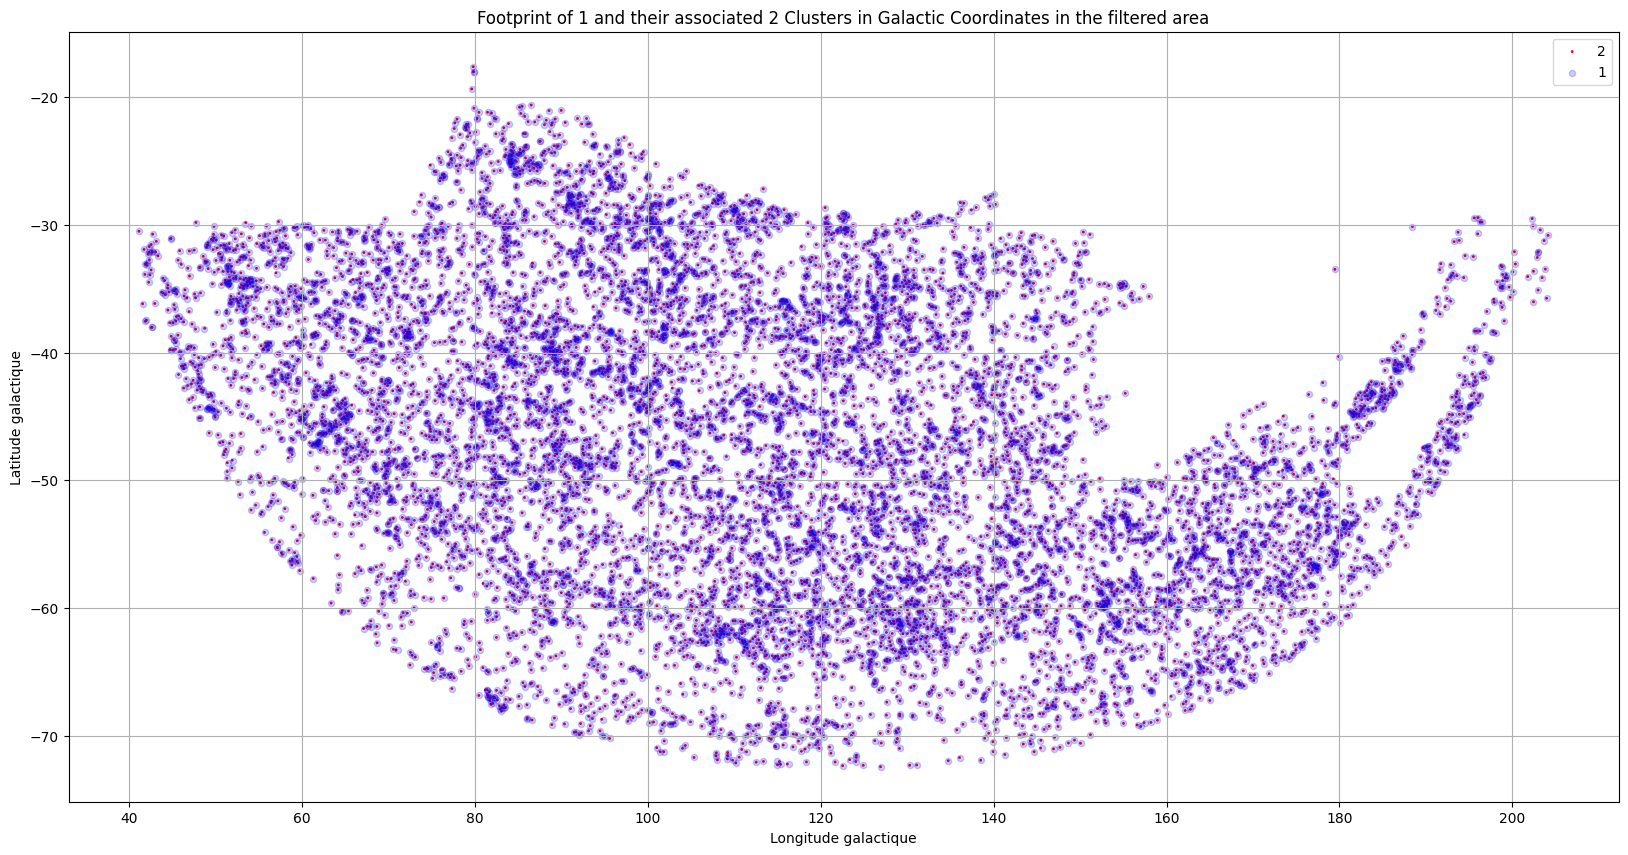

In [43]:
glon_2_associated_3D = table_2_associated_3D['glon'].tolist() ; glat_2_associated_3D = table_2_associated_3D['glat'].tolist()
glon_1_crossed_3D = table_1_crossed_3D['glon'].tolist() ; glat_1_crossed_3D = table_1_crossed_3D['glat'].tolist()


fig = plt.figure(figsize=(20, 10))
'''ax_projection_1 = plt.subplot(111)
ax_projection_2 = plt.subplot(111)'''
ax_projection_1_ = plt.subplot(111)
ax_projection_2_ = plt.subplot(111)


ax_projection_2_.scatter(glon_2_associated_3D, glat_2_associated_3D,s=1,edgecolors='red',facecolors='none',label='2') 
ax_projection_2_.grid(True)
ax_projection_2_.set_xlabel("Longitude galactique")
ax_projection_2_.set_ylabel("Latitude galactique")

ax_projection_1_.scatter(glon_1_crossed_3D, glat_1_crossed_3D, s=20,facecolors='blue',alpha=0.2,label='1') 
ax_projection_1_.grid(True)
ax_projection_1_.set_xlabel("Longitude galactique")
ax_projection_1_.set_ylabel("Latitude galactique")


plt.title(f"Footprint of 1 and their associated 2 Clusters in Galactic Coordinates in the filtered area")
plt.legend()


In [44]:
table_1_crossed_3D

,__indexes,glon,glat,_RAJ2000,_DEJ2000,Name,RAJ2000,DEJ2000,zph,zsp,...,N1Mpc,L1Mpc,Richness,M500,recno,z,id_asso_2,diff_z,dist_ang,id_associations
1735,1735,110.942314,-62.571951,7.36843,-0.21261,1735,7.36843,-0.21261,0.0528,0.05987,...,96,13.54177,25.54410,1.41,1736,0.05987,30817,0.00113,0.000022,"[1735, 30817]"
2644,2644,114.985870,-71.981073,10.37624,-9.26274,2644,10.37624,-9.26274,0.0546,0.00000,...,168,23.52083,52.17987,3.05,2645,0.05460,44959,0.00080,0.093274,"[2644, 44959]"
2979,2979,119.174452,-69.950588,11.56212,-7.11671,2979,11.56212,-7.11671,0.0478,0.05312,...,40,7.18219,10.85588,0.56,2980,0.05312,50525,0.00138,0.084299,"[2979, 50525]"
3149,3149,121.391249,-61.509552,12.12442,1.35340,3149,12.12442,1.35340,0.0544,0.00000,...,60,13.69479,25.53871,1.41,3150,0.05440,974715,0.00890,0.000120,"[3149, 974715]"
3210,3210,121.721037,-67.081311,12.38668,-4.21401,3210,12.38668,-4.21401,0.0510,0.05348,...,70,13.40582,24.76687,1.37,3211,0.05348,975336,0.00002,0.000022,"[3210, 975336]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372,5372,137.422274,-60.846512,19.86250,1.23471,5372,19.86250,1.23471,0.5836,0.61296,...,17,10.36456,60.91312,3.61,5373,0.61296,93351,0.00004,0.000041,"[5372, 93351]"
8943,8943,168.130695,-58.291957,34.79554,-3.34274,8943,34.79554,-3.34274,0.5590,0.61070,...,13,6.02250,29.62891,1.66,8944,0.61070,170566,0.00000,0.000014,"[8943, 170566]"
14399,14399,72.878210,-42.441048,338.14580,6.54538,14399,338.14580,6.54538,0.6133,0.00000,...,15,8.46556,46.66125,2.71,14400,0.61330,1534916,0.00680,0.010861,"[14399, 1534916]"
15465,15465,68.703500,-52.565974,343.27551,-2.62763,15465,343.27551,-2.62763,0.5715,0.61208,...,14,10.16785,59.29784,3.51,15466,0.61208,895466,0.00178,0.000050,"[15465, 895466]"


### table_1_crossed [DEPRECATED] (TO DO mettre à jour avec zone fiduciaire) 
Si un cluster A détecté en 1 est associé à 3 clusters détectés en 2, il n'y aura tout de même qu'une seule fois l'indice du cluster A dans la table "table_1_crossed" (pas de seuil sur la différence de z, association uniquement '2D').

In [45]:
#Pour chaque objet 1, on va identifier le nombre d'objets 2s associés, aisni que les indices de ces objets 2

associations_dict_1 = {}
for x in indices_1_crossed:
    associations_dict_1[x] = []
    for i in range(nb_bin_z):
        for float1, float2 in indices_crossed_list[i]:
            if float1 == x:
                associations_dict_1[x].append(float2)

#Maintenant, on va ajouter à chaque objet 1 le nombre d'objets 2 associés
for x in indices_1_crossed:
    num_associations = len(associations_dict_1[x])
    associations_dict_1[x] = (associations_dict_1[x], num_associations)

#On obtient un dictionnaire de la forme {indice_1 : (indices_objets_2, nombre_objets_2_associés)}
'''print("Format de chaque entrée du dictionnaire : (indice_x) : ((liste_indices_2s_associées),nombres d'objets dans 2 associé) : ",'\n' )
associations_dict_1'''
            

'print("Format de chaque entrée du dictionnaire : (indice_x) : ((liste_indices_2s_associées),nombres d\'objets dans 2 associé) : ",\'\n\' )\nassociations_dict_1'

Maintenant, on récupère dans la table 1 les objets qui ont une association :

In [46]:
table_1_crossed = table_1.loc[indices_1_crossed] #; table_1_crossed = table_1_crossed.reset_index(drop=True) # On reset l'index pour ne pas avoir de mismacth dans les calculs par la suite
#table_2_crossed = ta<<dble_2.iloc[indices_2_crossed] ; table_2_crossed = table_2_crossed.reset_index(drop=True)

In [48]:
#On calcule les informations d'associations "diff_z" et "dist_ang" pour chaque objet 1

diff_z_list = [] # Liste qui va contenir les différences de redshift entre l'objet 1 et l'ensemble des objets 2 associés
dist_ang_list = [] # Liste qui va contenir les distances angulaires entre l'objet 1 et l'ensemble des objets 2 associés
for index, x in table_1_crossed.iterrows():
    obj_2_ass = associations_dict_1[index][0] #liste des objets 2 associés à l'objet 1 courant
    diff_z = []
    dist_ang = []
    for j in range(len(obj_2_ass)): # On parcourt la liste des objets 2 associés à l'objet 1
        diff_z.append(abs(table_1_crossed['zBest'][index] - table_2_['zCl'][obj_2_ass[j]]))
        dist_ang.append(np.sqrt((table_1_crossed['RAJ2000'][index] - table_2_['RAJ2000'][obj_2_ass[j]])**2 + (table_1_crossed['DEJ2000'][index] - table_2_['DEJ2000'][obj_2_ass[j]])**2)) 
    diff_z_list.append(diff_z) # On ajoute la liste des différences de redshift à la liste diff_z_list
    dist_ang_list.append(dist_ang)
    #print(f"Index: {index}, Element: {x}")
    #print(associations_dict_1[i])
    # print(associations_dict_1[index])
    #print(associations_dict_1[index][0][j])
    """diff_z.append(abs(table_1_crossed['zBest'][i] - table_2['Z'][associations_dict_1[i][0]]))
    diff_z_list.append(diff_z)"""

KeyError: 'zBest'

In [49]:
# On ajoute les informations d'associations à table_1_crossed. En comparaison de ce qu'a fait Reza on a : Nb_assos <-> idm ; id_assos <-> idass ; diff_z <-> delz ; dist_ang <-> dstass  

#Nb_assos :
nb_assos_list = [x[1][1] for x in associations_dict_1.items()]
table_1_crossed['nb_assos'] = nb_assos_list

#id_assos :
id_assos_list = [x[1][0] for x in associations_dict_1.items()]
table_1_crossed['id_assos'] = id_assos_list

#diff_z
table_1_crossed['diff_z'] = diff_z_list

#dist_ang
table_1_crossed['dist_ang'] = dist_ang_list


ValueError: Length of values (0) does not match length of index (17775)

In [50]:
# On crée la table "2 associée" en ne conservant que les objets 2 associés à un objet 1

'flattened_list = [item for sublist in nested_list for item in sublist]'
id_assos_list_flatten = [id_assos for sublist in id_assos_list for id_assos in sublist] # On 'flatten' id_assos_list
table_2_associated = table_2.iloc[id_assos_list_flatten]

In [51]:
# TO DO Sélection zone fiduciaire (comme pour table_1_crossed_3D) : problème ici la colonne 'id_assos' de table_1_crossed est une liste de listes

'''table_1_crossed['distance'] = np.sqrt((table_1_crossed['glon'] - x_center)**2 + (table_1_crossed['glat'] - y_center)**2)
table_1_crossed = table_1_crossed[table_1_crossed['distance'] >= radius_]
table_1_crossed = table_1_crossed.drop(columns=['distance'])



table_1_crossed = table_1_crossed[(table_1_crossed['glon'] > min_glon)
                                    & ((table_1_crossed['glat'] >= borne_1_glat_) | (table_1_crossed['glat'] <= borne_2_glat_))
                                    ]


table_2_associated = table_2_associated.loc[table_1_crossed['id_asso']]'''

"table_1_crossed['distance'] = np.sqrt((table_1_crossed['glon'] - x_center)**2 + (table_1_crossed['glat'] - y_center)**2)\ntable_1_crossed = table_1_crossed[table_1_crossed['distance'] >= radius_]\ntable_1_crossed = table_1_crossed.drop(columns=['distance'])\n\n\n\ntable_1_crossed = table_1_crossed[(table_1_crossed['glon'] > min_glon)\n                                    & ((table_1_crossed['glat'] >= borne_1_glat_) | (table_1_crossed['glat'] <= borne_2_glat_))\n                                    ]\n\n\ntable_2_associated = table_2_associated.loc[table_1_crossed['id_asso']]"

In [52]:
table_1_crossed

,glon,glat,_RAJ2000,_DEJ2000,Name,RAJ2000,DEJ2000,zph,zsp,zphmedian,N1Mpc,L1Mpc,Richness,M500,recno,z,nb_assos,id_assos
1,98.536862,-57.460835,0.00635,2.95542,1,0.00635,2.95542,0.4571,0.42290,0.43890,17,6.56276,23.13604,1.27,2,0.42290,1,[71]
2,100.049582,-55.283444,0.00958,5.28826,2,0.00958,5.28826,0.1734,0.16936,0.17750,58,14.09044,35.83500,2.04,3,0.16936,5,"[17, 946313, 946646, 1581098, 1581113]"
3,110.350582,-29.827790,0.01474,31.78564,3,0.01474,31.78564,0.0824,0.00000,0.10490,64,12.95997,25.62747,1.42,4,0.08240,3,"[946502, 946540, 1581165]"
4,102.115166,-51.834197,0.01476,8.94881,4,0.01476,8.94881,0.2609,0.00000,0.27620,26,8.83946,24.11363,1.33,5,0.26090,1,[946567]
5,85.997870,-68.606443,0.01893,-9.50125,5,0.01893,-9.50125,0.3526,0.00000,0.36690,13,3.06561,7.30979,0.37,6,0.35260,1,[184]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19604,98.771770,-57.036173,359.96890,3.39711,19604,359.96890,3.39711,0.3011,0.00000,0.32125,29,14.51120,50.82675,2.97,19605,0.30110,2,"[946405, 946466]"
19605,104.141421,-47.645372,359.97270,13.33689,19605,359.97270,13.33689,0.2360,0.24498,0.23050,24,6.31375,14.90396,0.79,19606,0.24498,5,"[1581010, 1581115, 1581129, 1581157, 1581169]"
19606,98.856970,-56.958426,359.98382,3.48642,19606,359.98382,3.48642,0.5132,0.00000,0.51320,20,8.83291,40.95954,2.35,19607,0.51320,2,"[946405, 946446]"
19607,93.260257,-63.301439,359.98503,-3.43589,19607,359.98503,-3.43589,0.3251,0.00000,0.32065,26,8.59997,26.87073,1.49,19608,0.32510,1,[946451]


## Association 2 → 1

On utilise les mêmes paramètres que pour l'association 1→2 : il s'avère que l'association 2→1 (en tout cas pour les paramètres 30''/1 MPC/0.010 z) n'est pas équivalente à celle 1→2 : voir la différence de nombre d'associations à la fin, on retrouve une différenc de quelques % voire inférieure à 1%.

### Calcul des indices

In [53]:
# On commence par créer des listes de coordonnées (RAJ2000,DEJ2000) en récupérant les colonnes correspondantes sur les tables

liste_indexes_2_bins = []
liste_coords_2_bins = []
for x in table_2_list_bins:
    liste_indexes_2_bin = []
    liste_coords_2_bin = []
    for index,row in x.iterrows():         
        liste_indexes_2_bin.append(index) ; liste_coords_2_bin.append((row['RAJ2000'],row['DEJ2000']))
    liste_indexes_2_bins.append(liste_indexes_2_bin) ; liste_coords_2_bins.append(liste_coords_2_bin)

liste_coords_1_all = [] #Au contraire de liste_indexes_1, cette liste d'indexes ne sera pas coupé par bin de redshift
for index,row in table_1.iterrows():
    coord = (row['RAJ2000'],row['DEJ2000'])
    liste_coords_1_all.append(coord)

In [54]:
# TO DO ; trouver un moyen d'accélérer le calcul ! (voir cross_matching_1_2 _tentative_accel_calcul.ipynb)


print(name_indexes_crossed) #pour rappeler quels paramètres ont été utilisés

if RUN_2_1 :
    indices_crossed_2_1 = [] 
    for i in range(nb_bin_z):
        indices_crossed_2_1_current = match_celestial_objects_list_deg(liste_coords_2_bins[i],liste_coords_1_all,tol_ang_list[i])
        indices_crossed_2_1.append(indices_crossed_2_1_current)

        with open(os.path.join(folder_2_1_indexes, name_indexes_crossed), 'wb') as file:
            pickle.dump(indices_crossed_2_1, file)

#REMARQUE : Le calcul semble bcp plus rapide que dans le sens 1→2 ! Avec les params  0.5 arcmin | 1 MPc | 0.010 deltaz :  2m30 dans le sens 2→1 contre 1h30 dans le sens 1→2

SELECTED_0_5_arcmin__1_MPC__0_010_z.pkl


In [55]:
with open(os.path.join(folder_2_1_indexes, name_indexes_crossed), 'rb') as file:
    indices_crossed_2_1 = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: '../SCUSS_DESI/indexes_crossed/Wen_2024_DESI_Legacy_TO_SCUSS_Gao_2020/SELECTED_0_5_arcmin__1_MPC__0_010_z.pkl'

In [56]:
indices_crossed_2_1_list = []

for i in range(nb_bin_z):
    indices_crossed_2_1_list_bin = []
    for j in range(len(indices_crossed_2_1[i])):
        indices_crossed_2_1_list_bin.append([liste_indexes_2_bins[i][indices_crossed_2_1[i][j][0]],indices_crossed_2_1[i][j][1]]) # le "vrai" indice 1 remplace celui qui permettait de le retrouver dans la liste des coordonnées par bin de redshift 
    indices_crossed_2_1_list.append(indices_crossed_2_1_list_bin)


NameError: name 'indices_crossed_2_1' is not defined

In [57]:
# Ici, on récupère les indices pour chaque association, un indice 2 est donc répété autant de fois que ce cluster est associé à un cluster 1 (si un cluster A détecté en 2 est associé à 3 clusters détectés en 1,
# il y aura 3 fois l'indices du cluster A dans la liste "indices_2_crossed_repetitifs")
indices_2_crossed_repetitifs = []
indices_1_repetitifs = []
for indices_crossed_2_1_list_bin in indices_crossed_2_1_list:
    for x in indices_crossed_2_1_list_bin :
        indices_2_crossed_repetitifs.append(x[0])
        indices_1_repetitifs.append(x[1])   

In [58]:
# Ici, on ne garde qu'une seule occurrence de chaque cluster 2 associé à au moins un cluster 1 (si un cluster A détecté en 2 est associé à 3 clusters détectés en 1, il n'y aura tout de même qu'une seule fois l'indice
# du cluster A dans la liste "indices_2_crossed")
number_of_duplicates_2 = 0
indices_2_crossed = set()
for indices_crossed_2_1_list_bin in indices_crossed_2_1_list:
    for float1, float2 in indices_crossed_2_1_list_bin:
        if float1 in indices_2_crossed:
            number_of_duplicates_2 += 1
        else:
            indices_2_crossed.add(float1)
indices_2_crossed = sorted(indices_2_crossed)
print(f"Proportion de duplicats par rapport an nombre de galaxies en 2: {round(number_of_duplicates_2/len(table_1) * 100,3)} %")

Proportion de duplicats par rapport an nombre de galaxies en 2: 0.0 %


In [59]:
len(indices_2_crossed_repetitifs)

0

In [60]:
len(indices_1_crossed_repetitifs)

39983

### table_2_crossed_3D

In [61]:
# Il peut y avoir plusieurs occurences d'un même objet 1 dans cette liste
table_2_crossed_repetitifs = table_2.loc[indices_2_crossed_repetitifs]
table_2_crossed_repetitifs['__indexes'] = indices_2_crossed_repetitifs
# Reorder columns to place '__indexes' at the first position
table_2_crossed_repetitifs = table_2_crossed_repetitifs[['__indexes'] + [col for col in table_2_crossed_repetitifs.columns if col != '__indexes']]

In [62]:
# On réindice pour que les indices correpondent à l'ordre des positions dans la table
table_1_ = table_1.reset_index(drop=True)
table_2_ = table_2.reset_index(drop=True)

diff_z_list_repetitif = []
dist_ang_list_repetitif = []

for i in range(len(table_2_crossed_repetitifs)):
    index_2 = indices_2_crossed_repetitifs[i] ; index_1 = indices_1_repetitifs[i]

    Opt_row_of_interest = table_2_crossed_repetitifs[table_2_crossed_repetitifs['__indexes'] == index_2].iloc[0] #On ne sélectionne qu'une seule ligne parmi ses éventuelles occurrences

    diff_z = abs(Opt_row_of_interest['z'] - table_1_.loc[index_1]['z']) 
    diff_z_list_repetitif.append(diff_z)
    dist_ang = np.sqrt((Opt_row_of_interest['RAJ2000'] - table_1_['RAJ2000'][index_1])**2 + (Opt_row_of_interest['DEJ2000'] - table_1_['DEJ2000'][index_1])**2)
    dist_ang_list_repetitif.append(dist_ang)
    
table_2_crossed_repetitifs['id_asso_1'] = indices_1_repetitifs
table_2_crossed_repetitifs['diff_z'] = diff_z_list_repetitif
table_2_crossed_repetitifs['dist_ang'] = dist_ang_list_repetitif

# On applique le seuil de redshift pour ne conserver que les assocciations qui ne sont pas trop éloignées en redshift
table_2_crossed_3D = table_2_crossed_repetitifs[table_2_crossed_repetitifs['diff_z'] < delta_z]
print(np.round((1-(len(table_2_crossed_3D)/len(table_2_crossed_repetitifs)))*100,1), " % des associations sont éliminées par le critère de redshift") 

#O récupère dans une table "table_1_associated_3D" les objets 1 associés à un objet 2
table_1_associated_3D = table_1_.loc[table_2_crossed_3D['id_asso_1']]
table_1_associated_3D['id_asso_2'] = table_2_crossed_3D['__indexes'].tolist()

associations_2_1 = []
for index,x in table_2_crossed_3D.iterrows():
    current_asso = [0,0]
    current_asso[0] = int(x['__indexes']) ; current_asso[1] = int(x['id_asso_1'])
    associations_2_1.append(current_asso)

table_2_crossed_3D['id_associations'] = associations_2_1 ; table_1_associated_3D['id_associations'] = associations_2_1


'''# Sélection zone fiduciaire (pour éviter d'avoir des objets 2 dont l'association 1 a été précédemment filtrée ←→ séparation de couples)

seuil_fiduciaire = 1 
radius_ = radius + seuil_fiduciaire ; borne_1_glat_ = borne_1_glat - seuil_fiduciaire ; borne_2_glat_ = borne_2_glat + seuil_fiduciaire ; min_glon = min_glon + seuil_fiduciaire

table_2_crossed_3D['distance'] = np.sqrt((table_2_crossed_3D['glon'] - x_center)**2 + (table_2_crossed_3D['glat'] - y_center)**2)
table_2_crossed_3D = table_2_crossed_3D[table_2_crossed_3D['distance'] >= radius_]
table_2_crossed_3D = table_2_crossed_3D.drop(columns=['distance'])



table_2_crossed_3D = table_2_crossed_3D[(table_2_crossed_3D['glon'] > min_glon)
                                    & ((table_2_crossed_3D['glat'] <= borne_1_glat_) | (table_2_crossed_3D['glat']>= borne_2_glat_))
                                    ]


table_1_associated_3D = table_1_associated_3D[table_1_associated_3D['id_associations'].isin(table_2_crossed_3D['id_associations'].tolist())] # On ne conserve ques les associations dont les objets 2 sont dans la zone fiduciaire : cela permet d'éviter 
                                                                                                                                               # la séparation de couples (si le 'seuil_fiduciaire' est assez grand)'''

ZeroDivisionError: division by zero

In [63]:
glon_1_associated_3D = table_1_associated_3D['glon'].tolist() ; glat_1_associated_3D = table_1_associated_3D['glat'].tolist()
glon_2_crossed_3D = table_2_crossed_3D['glon'].tolist() ; glat_2_crossed_3D = table_2_crossed_3D['glat'].tolist()


fig = plt.figure(figsize=(20, 10))
'''ax_projection_1 = plt.subplot(111)
ax_projection_2 = plt.subplot(111)'''
ax_projection_1_ = plt.subplot(111)
ax_projection_2_ = plt.subplot(111)


ax_projection_2_.scatter(glon_2_crossed_3D, glat_2_crossed_3D,s=1,edgecolors='red',facecolors='none',label='2') 
ax_projection_2_.grid(True)
ax_projection_2_.set_xlabel("Longitude galactique")
ax_projection_2_.set_ylabel("Latitude galactique")

ax_projection_1_.scatter(glon_1_associated_3D, glat_1_associated_3D, s=20,facecolors='blue',alpha=0.2,label='1') 
ax_projection_1_.grid(True)
ax_projection_1_.set_xlabel("Longitude galactique")
ax_projection_1_.set_ylabel("Latitude galactique")


plt.title(f"Footprint of Optical and their associated 1 Clusters in Galactic Coordinates in the filtered area")
plt.legend()

NameError: name 'table_1_associated_3D' is not defined

In [64]:
if len(table_2_crossed_3D) == len(table_1_crossed_3D):
    print("On a le même nombre d'associations dans le cas où on centre l'association autour d'un objet central 1 ou 2")
else :
    print("On a pas le même nombre d'associations dans le cas où on centre l'association autour d'un objet central 1 ou 2\n")
    print("Pourcentage de différence entre la méthode 1→2 et la méthode 2→1 : ",round((1-(len(table_2_crossed_3D)/len(table_1_crossed_3D)))*100,1), " %")


On a pas le même nombre d'associations dans le cas où on centre l'association autour d'un objet central 1 ou 2

Pourcentage de différence entre la méthode 1→2 et la méthode 2→1 :  100.0  %


# Visualisation résultats associations 

In [65]:
index_2_associated_3D = table_2_associated_3D.index.tolist()
table_2_associated_3D['__indexes'] = index_2_associated_3D
table_2_associated_3D = table_2_associated_3D[['__indexes'] + [col for col in table_2_associated_3D.columns if col != '__indexes']]
table_2_associated_3D

,__indexes,glon,glat,_RAJ2000,_DEJ2000,ID,n_Name,Name,RAJ2000,DEJ2000,...,M500,Ngal,Gamma,e_Gamma,imag_,Cat,recno,z,id_asso_1,id_associations
30817,30817,110.942327,-62.571973,7.36844,-0.21263,30818,,J002928.4-001245,7.36844,-0.21263,...,1.55,31,-0.44,0.13,1,WHL,30818,0.0610,1735,"[1735, 30817]"
44959,44959,115.236415,-72.031330,10.46032,-9.30312,44960,,J004150.5-091811,10.46032,-9.30312,...,2.47,52,-0.45,0.10,1,WHL,44960,0.0554,2644,"[2644, 44959]"
50525,50525,119.209892,-69.867178,11.56945,-7.03273,50526,,J004616.7-070158,11.56945,-7.03273,...,0.61,11,0.00,0.00,1,AMF,50526,0.0545,2979,"[2979, 50525]"
974715,974715,121.391442,-61.509474,12.12451,1.35348,974716,,J004829.9+012113,12.12451,1.35348,...,1.70,25,0.00,0.00,2,AMF,974716,0.0633,3149,"[3149, 974715]"
975336,975336,121.721062,-67.081331,12.38669,-4.21403,975337,,J004932.8-041251,12.38669,-4.21403,...,0.53,12,0.00,0.00,2,AMF,975337,0.0535,3210,"[3210, 975336]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93351,93351,137.422275,-60.846471,19.86251,1.23475,93352,,J011927.0+011405,19.86251,1.23475,...,2.16,22,0.00,0.00,1,WHL,93352,0.6130,5372,"[5372, 93351]"
170566,170566,168.130721,-58.291958,34.79555,-3.34275,170567,WH-,J021910.9-032034,34.79555,-3.34275,...,1.13,9,0.00,0.00,1,,170567,0.6107,8943,"[8943, 170566]"
1534916,1534916,72.878502,-42.451872,338.15344,6.53766,1534917,,J223236.8+063216,338.15344,6.53766,...,5.22,56,-2.16,0.12,2,WHL,1534917,0.6065,14399,"[14399, 1534916]"
895466,895466,68.703513,-52.565924,343.27548,-2.62759,895467,,J225306.1-023739,343.27548,-2.62759,...,3.52,33,0.12,0.05,1,WHL,895467,0.6103,15465,"[15465, 895466]"


In [66]:
table_2_associated_3D.columns

Index(['__indexes', 'glon', 'glat', '_RAJ2000', '_DEJ2000', 'ID', 'n_Name',
       'Name', 'RAJ2000', 'DEJ2000', 'zCl', 'f_zCl', 'zmag', 'W1mag', 'logMs',
       'r500', 'lam500', 'M500', 'Ngal', 'Gamma', 'e_Gamma', 'imag_', 'Cat',
       'recno', 'z', 'id_asso_1', 'id_associations'],
      dtype='object')

In [67]:
table_1_crossed_3D.columns

Index(['__indexes', 'glon', 'glat', '_RAJ2000', '_DEJ2000', 'Name', 'RAJ2000',
       'DEJ2000', 'zph', 'zsp', 'zphmedian', 'N1Mpc', 'L1Mpc', 'Richness',
       'M500', 'recno', 'z', 'id_asso_2', 'diff_z', 'dist_ang',
       'id_associations'],
      dtype='object')

In [68]:
# Quantités intéressantes

diff_z = table_1_crossed_3D['diff_z'] # Différence de redshift entre l'objet 1 et l'objet 2 associé
indexes_1_crossed_3D = table_1_crossed_3D['__indexes'] 

#Optique
N_gal = table_2_associated_3D['Ngal']
richness = table_2_associated_3D['lam500'] # Richness : mass proxy → define eq 2 in Wen 2024
M_500_2 = np.array(table_2_associated_3D['M500'])


#1
M500_1 = np.array(table_1_crossed_3D['M500'])
#kT_1 = np.array(table_1_crossed_3D['KT']) #Temperature en keV
#CR500_1 = np.array(table_1_crossed_3D['CR500']) # Count Rate en counts/s depuis la sphère de rayon R500
#dz_x_mean = table_1_crossed_3D['e_zBest'].mean() # moyenne des erreurs de redshift des objets 1

In [69]:
nb_nan_M_500_1 = table_1_crossed_3D["M500"].isna().sum()
print(f"Nombre de valeurs NaN dans la colonne M500_1 : {nb_nan_M_500_1}")

nb_nan_M_500_2 = table_2_associated_3D["M500"].isna().sum()
print(f"Nombre de valeurs NaN dans la colonne M500_2 : {nb_nan_M_500_2}")

Nombre de valeurs NaN dans la colonne M500_1 : 0
Nombre de valeurs NaN dans la colonne M500_2 : 0


In [70]:
ratio_M500_1_2 = M500_1 / M_500_2
diff_M500_1_2 =((M500_1 - M_500_2) / M_500_2)*100

In [71]:
dDelta_r_list = [] # Liste qui va contenir les erreurs de la distance de ligne de visée (en valeur absolue) entre l'objet 1 et l'objet 2 associé

for i in range(len(table_1_crossed_3D)):
    object_1 = table_1_crossed_3D.iloc[i]
    object_2 = table_2_associated_3D.iloc[i]

    z_x = object_1['z'] # Redshift objet 1
    # Erreur sur le redshift de l'objet 1
    dz_x = object_1['e_zBest']
    if np.isnan(dz_x): # On vérifie si la valeur est NaN
        dz_x = dz_x_mean # On remplace la valeur NaN par la moyenne des erreurs de redshift des objets 1

    z_2 = object_2['zCl'] # Redshift objet 2
    # Erreur sur le redshift de l'objet 2
    f_zCl = object_2['f_zCl'] # Indique si le redshift est photométrique (f_zCl=0) ou spectroscopique (f_zCl=1)
    if f_zCl == 0: # redshift photométrique
        dz_2 = 0.010
    else: # redshift spectroscopique
        dz_2 = 0.00001 #Erreur caractéristique des redshifts spectroscopiques (A VERIFIER)

    Delta_r = (cosmo.angular_diameter_distance(z_x).value - cosmo.angular_diameter_distance(z_2).value)

    #Delta_r_squared = (cosmo.angular_diameter_distance(z_x).value - cosmo.angular_diameter_distance(z_2).value)**2
    #print(f"Delta_r_squared : {Delta_r_squared}")

    #Calcul numériqued de la dérivée de la distance de ligne de visée (choix de la distance de diamètre angulaire)
    #Pour les objets 1
    r_x_plus = cosmo.angular_diameter_distance(z_x + dz_x).value
    r_x_minus = cosmo.angular_diameter_distance(z_x - dz_x).value
    dr_x = (r_x_plus - r_x_minus) / (2 * dz_x)  # Dérivée centrée

    #Pour les objets 2
    r_2_plus = cosmo.angular_diameter_distance(z_2 + dz_2).value
    r_2_minus = cosmo.angular_diameter_distance(z_2 - dz_2).value
    dr_2 = (r_2_plus - r_2_minus) / (2 * dz_2)  # Dérivée centrée

    #Calcul de l'erreur du CARRE de la distance de ligne de visée
    dDelta_r = dr_x*dz_x - dr_2*dz_2  
    dDelta_r_list.append(np.abs(dDelta_r))  # On ajoute l'erreur de la distance de ligne de visée à la liste


# Compter la proportion de NaN dans dDelta_r_list
dDelta_r_array = np.array(dDelta_r_list)
nb_nan = np.isnan(dDelta_r_array).sum()
proportion_nan = nb_nan / len(dDelta_r_array) * 100
print(f"Nombre de NaN : {nb_nan}")
print(f"Proportion de NaN : {proportion_nan:.2f} %")

KeyError: 'e_zBest'

ValueError: x and y must have same first dimension, but have shapes (0,) and (10348,)

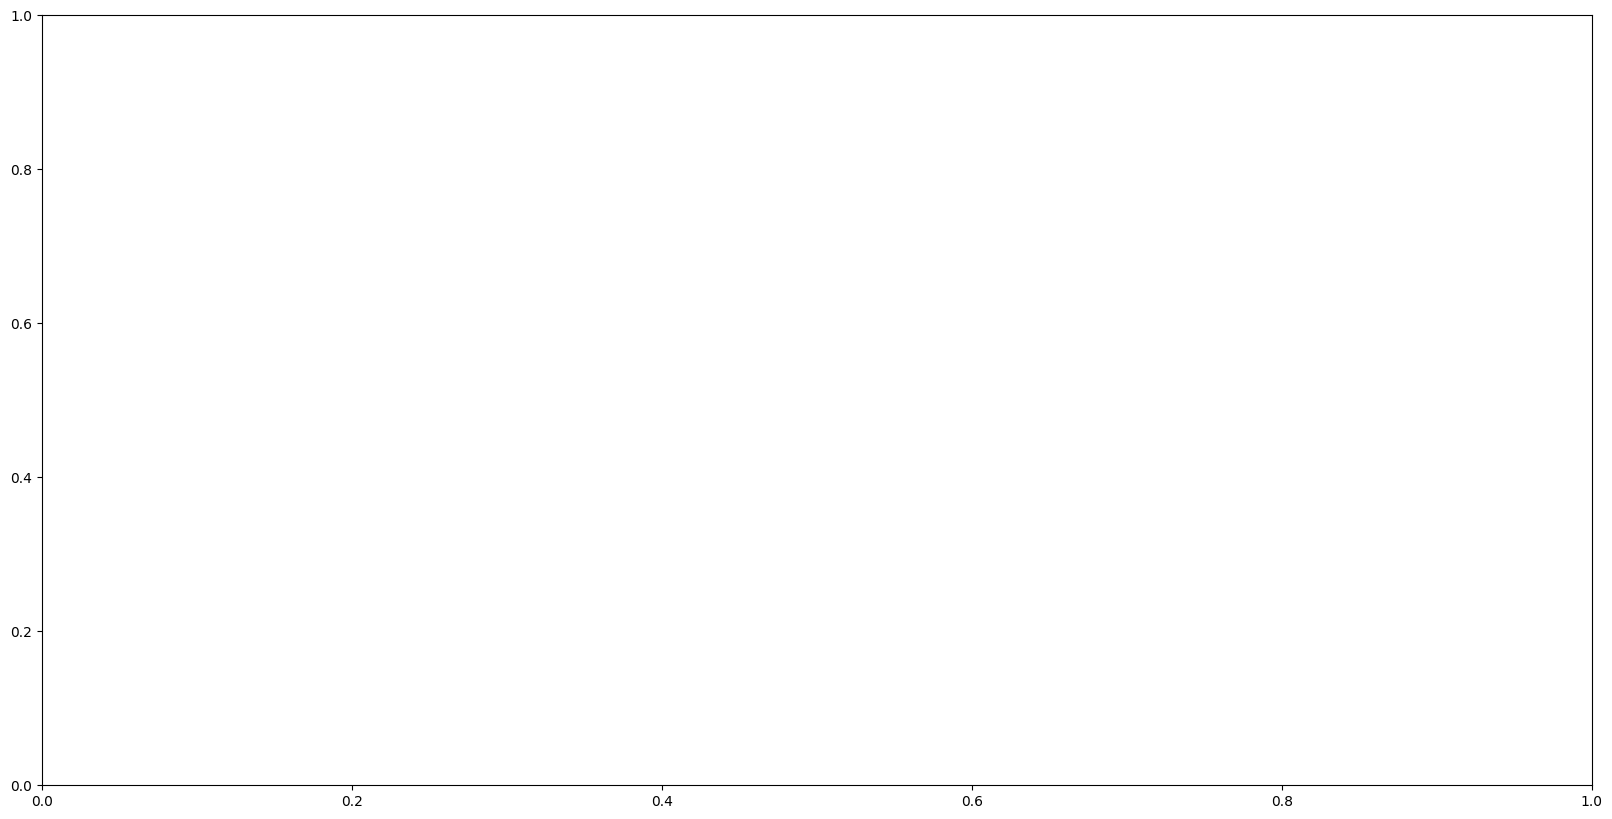

In [72]:
#On va afficher la différence de masse entre les deux éléments de l'association en fonction de la différence de l'erreur de la distance de ligne de visée
plt.figure(figsize=(20, 10))
plt.plot(dDelta_r_list, diff_M500_1_2, 'o', markersize=3)
plt.axhline(y=1, color='green', linestyle='--', label=f'diff = 0%')
plt.axhline(y=-100, color='red', linestyle='--', label=f'diff = -100%')
plt.axhline(y=100, color='red', linestyle='--', label=f'diff = 100%')
plt.xlabel("Erreur de la distance de ligne de visée (en MPC)")
plt.ylabel('(M500_1 - M_500_2 / M_500_2)*100 (%)')
plt.title("Différence (en %) entre M500_1 et M500_2 en fonction de l'erreur de distance sur la ligne de visée")
plt.xscale('log')
plt.legend()

output_path = os.path.join(folder_plots, "diff_M500_1_2_vs_err_dist.png")
plt.savefig(output_path, dpi=300)

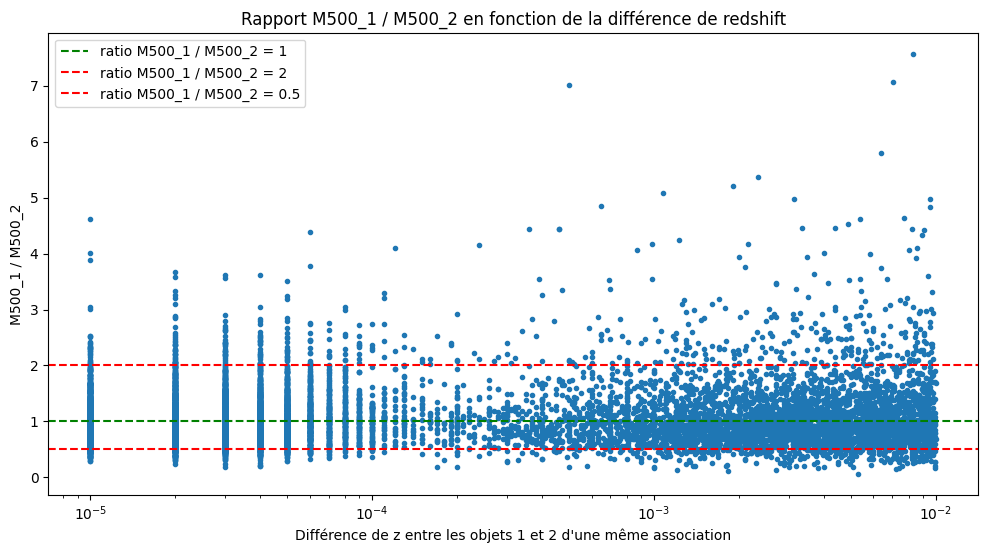

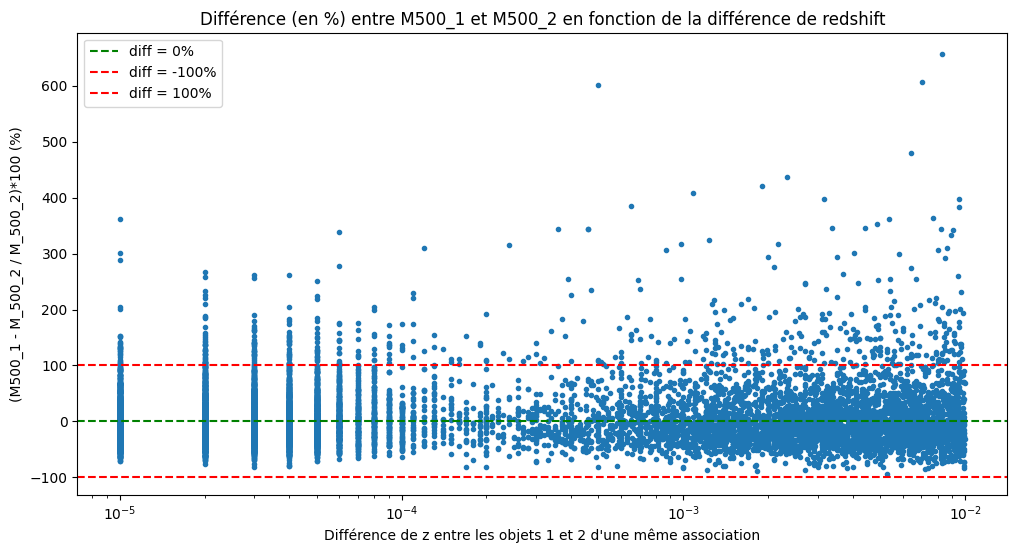

In [73]:
plt.figure(figsize=(12, 6))
plt.plot(diff_z, ratio_M500_1_2, 'o', markersize=3)
plt.axhline(y=1, color='green', linestyle='--', label=f'ratio M500_1 / M500_2 = 1')
plt.axhline(y=2, color='red', linestyle='--', label=f'ratio M500_1 / M500_2 = 2')
plt.axhline(y=0.5, color='red', linestyle='--', label=f'ratio M500_1 / M500_2 = 0.5')
plt.xlabel("Différence de z entre les objets 1 et 2 d'une même association")
plt.ylabel('M500_1 / M500_2')
plt.title('Rapport M500_1 / M500_2 en fonction de la différence de redshift')
plt.xscale('log')
plt.legend()

output_path = os.path.join(folder_plots, "ratio_M500_1_2_vs_diff_z.png")
plt.savefig(output_path, dpi=300)

plt.figure(figsize=(12, 6))
plt.plot(diff_z, diff_M500_1_2, 'o', markersize=3)
plt.axhline(y=1, color='green', linestyle='--', label=f'diff = 0%')
plt.axhline(y=-100, color='red', linestyle='--', label=f'diff = -100%')
plt.axhline(y=100, color='red', linestyle='--', label=f'diff = 100%')
plt.xlabel("Différence de z entre les objets 1 et 2 d'une même association")
plt.ylabel('(M500_1 - M_500_2 / M_500_2)*100 (%)')
plt.title('Différence (en %) entre M500_1 et M500_2 en fonction de la différence de redshift')
plt.xscale('log')
plt.legend()

output_path = os.path.join(folder_plots, "diff_M500_1_2_vs_diff_z.png")
plt.savefig(output_path, dpi=300)


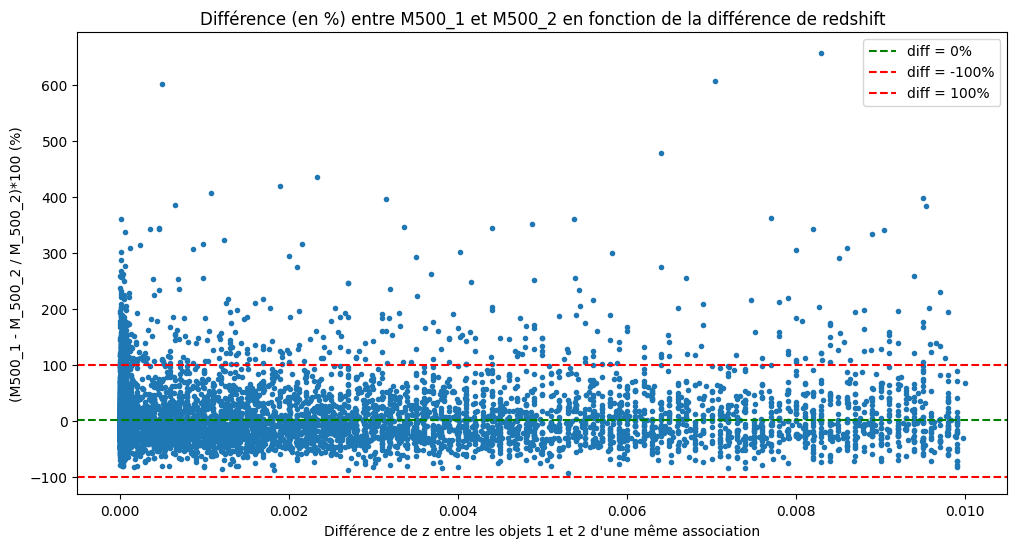

In [74]:
plt.figure(figsize=(12, 6))
plt.plot(diff_z, diff_M500_1_2, 'o', markersize=3)
plt.axhline(y=1, color='green', linestyle='--', label=f'diff = 0%')
plt.axhline(y=-100, color='red', linestyle='--', label=f'diff = -100%')
plt.axhline(y=100, color='red', linestyle='--', label=f'diff = 100%')
plt.xlabel("Différence de z entre les objets 1 et 2 d'une même association")
plt.ylabel('(M500_1 - M_500_2 / M_500_2)*100 (%)')
plt.title('Différence (en %) entre M500_1 et M500_2 en fonction de la différence de redshift')
#plt.xscale('log')
plt.legend()

'output_path = os.path.join(folder_plots, "histo_log_diff_z.png")\nplt.savefig(output_path, dpi=300)'

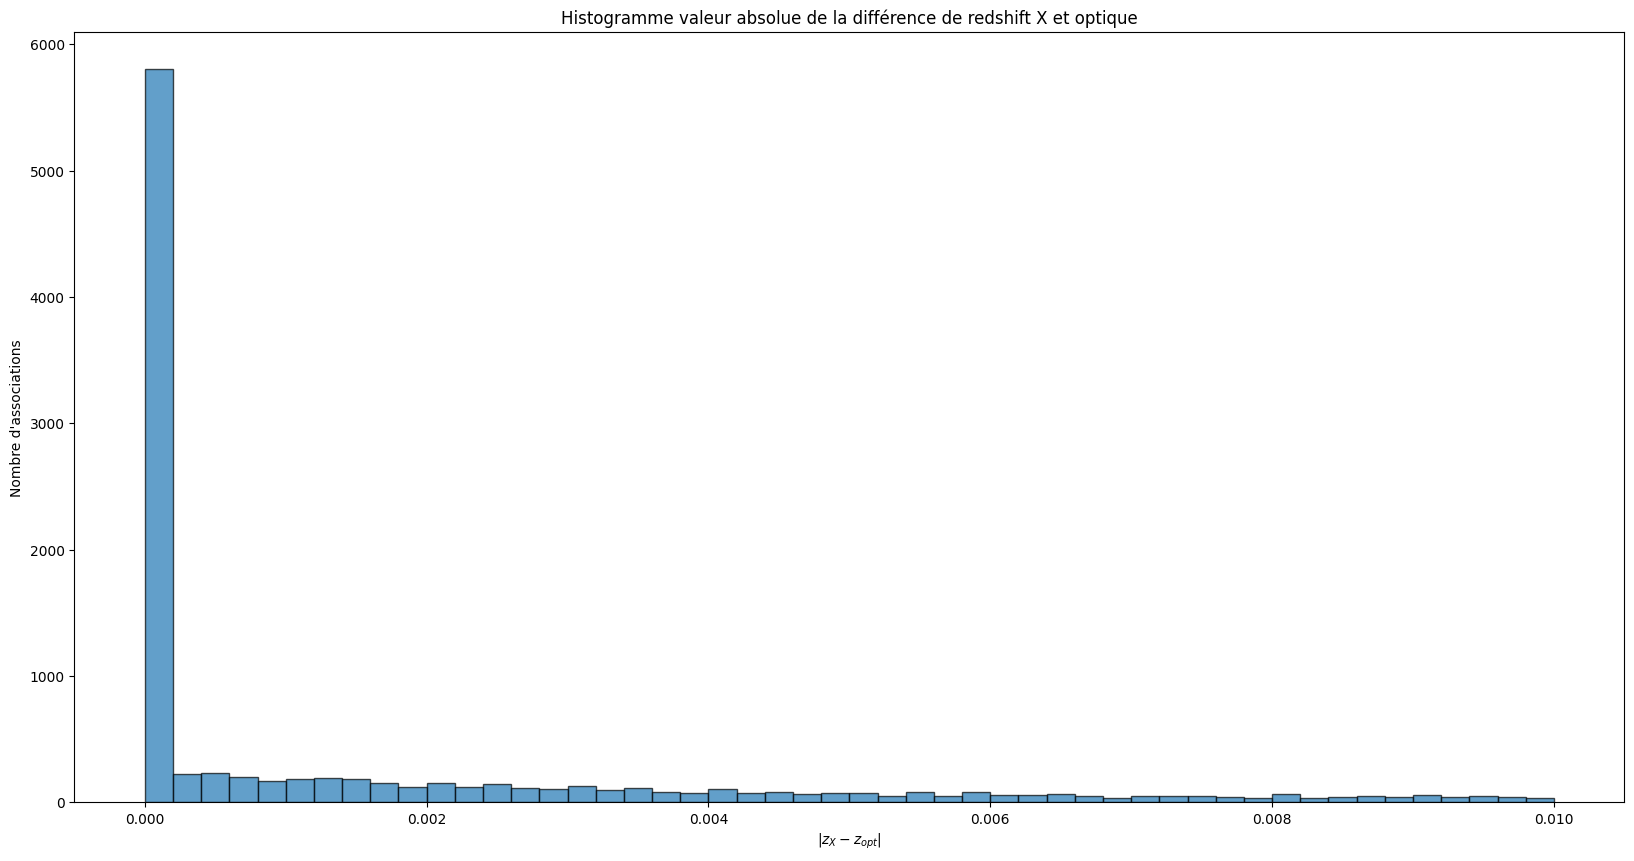

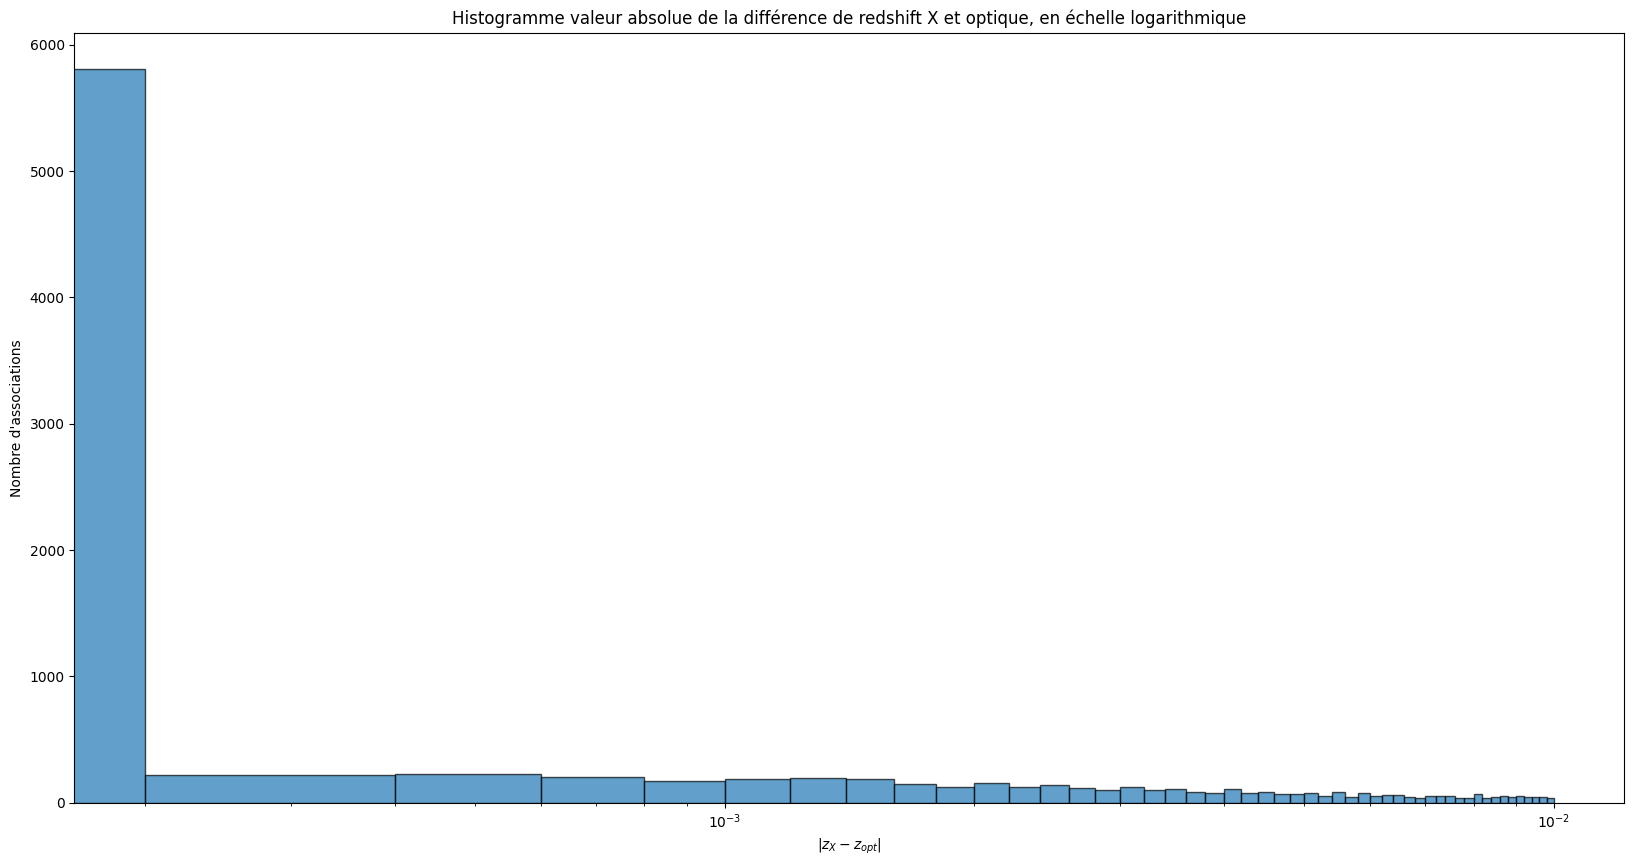

In [75]:
# Histogramme différence de redshift par association
plt.figure(figsize=(20, 10))
plt.hist(diff_z, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel(r'$|z_X - z_{opt}|$')
plt.ylabel('Nombre d\'associations')
plt.title('Histogramme valeur absolue de la différence de redshift X et optique')

'''output_path = os.path.join(folder_plots, "histo_diff_z.png")
plt.savefig(output_path, dpi=300)'''

plt.figure(figsize=(20, 10))
plt.hist(diff_z, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel(r'$|z_X - z_{opt}|$')
plt.xscale('log')
plt.ylabel('Nombre d\'associations')
plt.title('Histogramme valeur absolue de la différence de redshift X et optique, en échelle logarithmique')

'''output_path = os.path.join(folder_plots, "histo_log_diff_z.png")
plt.savefig(output_path, dpi=300)'''

In [76]:
diff_z_null = [x for x in diff_z if x < 10e-7] # on récupère les associations possédant les m^mes z (une différence inférieure à 10^-7 ne peut ni corresoindr à une distance entre amas différents, ni à une erreur de mesure)
prop_true_z = (len(diff_z_null) / len(diff_z)) * 100
print(f"Proportion d'associations avec des redshifts identiques : {round(prop_true_z, 2)} %")

Proportion d'associations avec des redshifts identiques : 4.65 %


'output_path = os.path.join(folder_plots, "hist_nb_assos_par_objet_1.png")\nplt.savefig(output_path, dpi=300)'

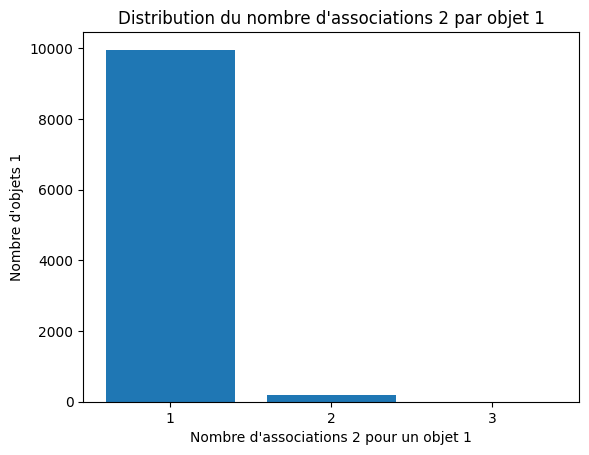

In [77]:
# Histogramme du nombre d'associations 2 pour un objet 1


# Compte le nombre d'occurrences de chaque index (nombre d'associations pour chaque objet 1)
nb_assos_counter = Counter(indexes_1_crossed_3D) # dictionnaire avec les index 1 comme clés et le nombre d'associations 2 comme valeurs
nb_assos_list = list(nb_assos_counter.values())


plt.figure()
bins = range(int(min(nb_assos_list)), int(max(nb_assos_list)) + 2)  # +2 pour inclure la dernière valeur entière
plt.hist(nb_assos_list, bins=bins, rwidth=0.8, align='left')
plt.xticks(range(int(min(nb_assos_list)), int(max(nb_assos_list)) + 1))
plt.xlabel("Nombre d'associations 2 pour un objet 1")
plt.ylabel("Nombre d'objets 1")
plt.title("Distribution du nombre d'associations 2 par objet 1")

'''output_path = os.path.join(folder_plots, "hist_nb_assos_par_objet_1.png")
plt.savefig(output_path, dpi=300)'''

In [78]:
# Calcul proportion d'associations 1 → 2 non-univoques
nb_asso_bins = list(Counter(nb_assos_list).values())
ratio_univoques = (nb_asso_bins[0] / len(indexes_1_crossed_3D)) * 100 
print(f"Proportion d'associations 1 → 2 univoques : {round(ratio_univoques, 2)} %")

Proportion d'associations 1 → 2 univoques : 96.21 %


'output_path = os.path.join(folder_plots, "richesse_2_vs_M500.png")\nplt.savefig(output_path, dpi=300)'

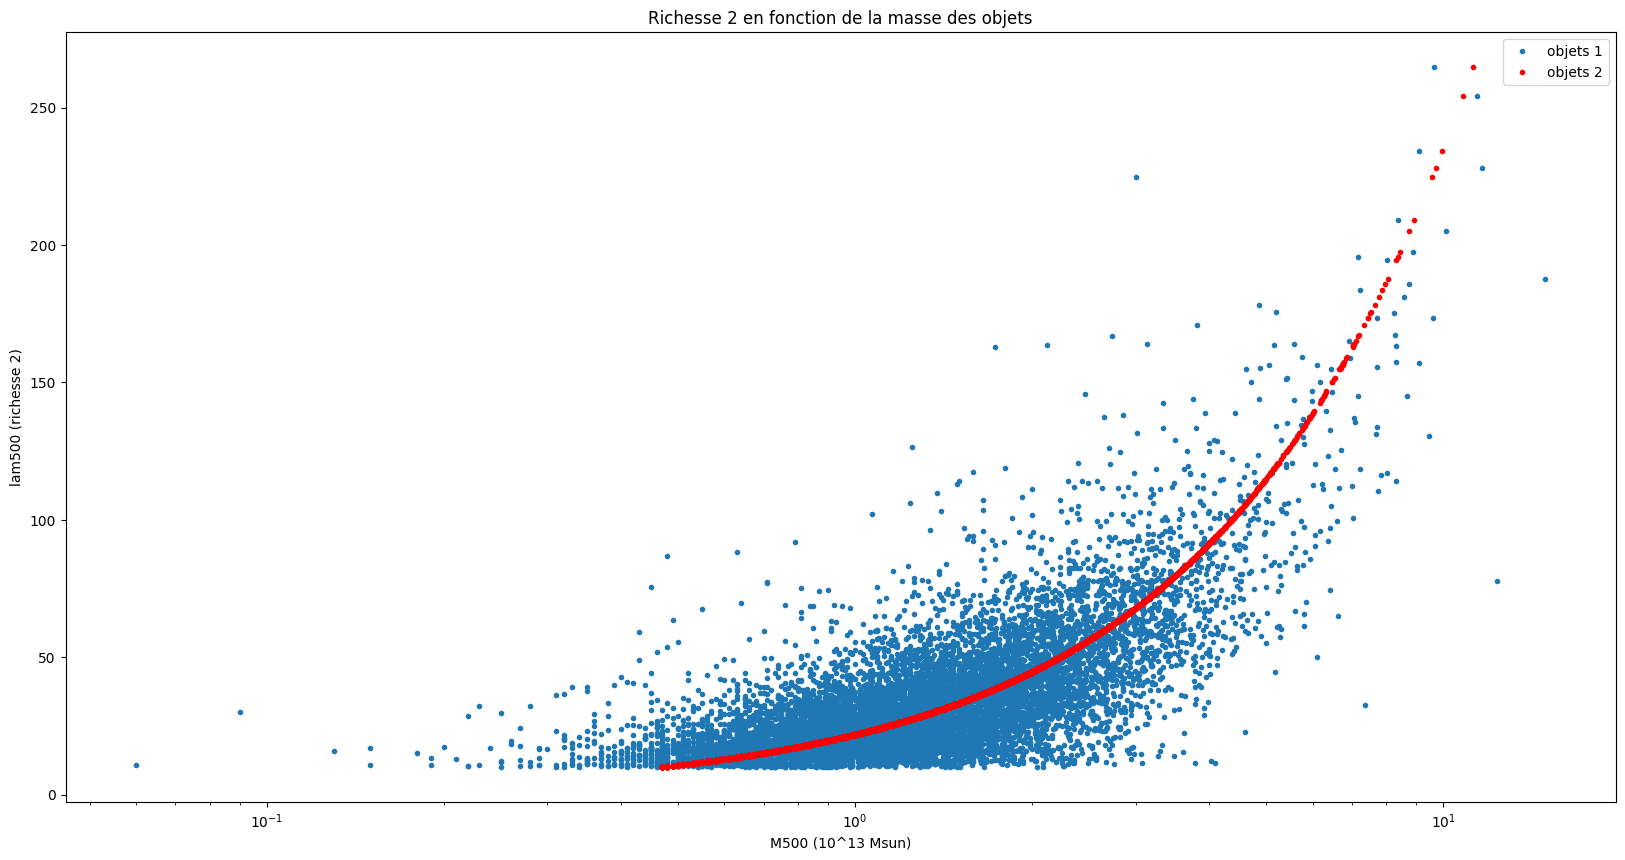

In [79]:
# graphe richesse 2 - M500


plt.figure(figsize=(20, 10))
plt.plot(M500_1, richness, 'o', markersize=3,label='objets 1')
plt.plot(M_500_2, richness, 'o', color='red', markersize=3,label='objets 2')
plt.xlabel('M500 (10^13 Msun)')
plt.ylabel('lam500 (richesse 2)')
plt.title('Richesse 2 en fonction de la masse des objets')
plt.xscale('log')
plt.legend()


'''output_path = os.path.join(folder_plots, "richesse_2_vs_M500.png")
plt.savefig(output_path, dpi=300)'''

In [80]:
borne_M_min = 0.5 ; borne_M_max = 5 # bornes de la masse M500 en 10^13 Msun
table_1_crossed_3D_filtered = table_1_crossed_3D[(table_1_crossed_3D['M500'] >= borne_M_min) & (table_1_crossed_3D['M500'] <= borne_M_max)]
table_2_associated_3D_filtered = table_2_associated_3D[table_2_associated_3D['id_associations'].isin(table_1_crossed_3D_filtered['id_associations'].tolist())]

print(len(table_1_crossed_3D_filtered))
print(len(table_2_associated_3D_filtered))


9918
9918


In [81]:
M500_1_filtered = table_1_crossed_3D_filtered['M500']
M500_2_filtered = table_2_associated_3D_filtered['M500']
richness_filtered = table_2_associated_3D_filtered['lam500']
richness_filtered = table_2_associated_3D_filtered['lam500']

'output_path = os.path.join(folder_plots, "richesse_2_vs_M500_bornes.png")\nplt.savefig(output_path, dpi=300)'

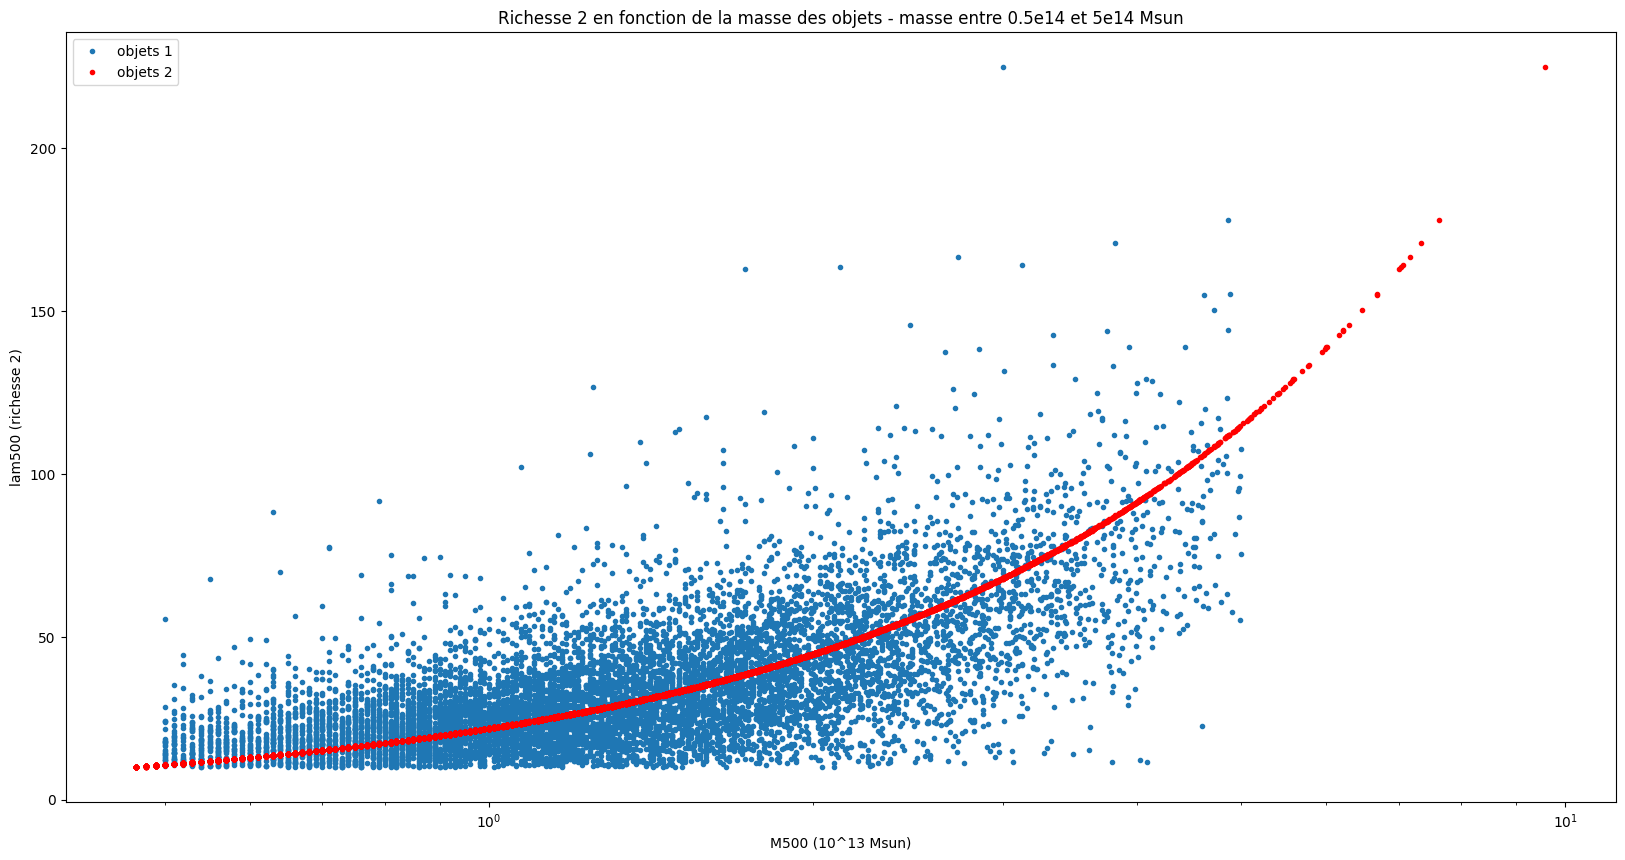

In [82]:
plt.figure(figsize=(20, 10))
plt.plot(M500_1_filtered, richness_filtered, 'o', markersize=3,label='objets 1')
plt.plot(M500_2_filtered, richness_filtered, 'o', color='red', markersize=3,label='objets 2')
plt.xlabel('M500 (10^13 Msun)')
plt.ylabel('lam500 (richesse 2)')
plt.title(f'Richesse 2 en fonction de la masse des objets - masse entre {borne_M_min}e14 et {borne_M_max}e14 Msun')
plt.xscale('log')
plt.legend()

'''output_path = os.path.join(folder_plots, "richesse_2_vs_M500_bornes.png")
plt.savefig(output_path, dpi=300)'''

In [83]:
# graphe T1 - M500


plt.figure(figsize=(20, 10))
plt.plot(M500_1, kT_1, 'o', markersize=3,label='objets 1')
plt.plot(M_500_2, kT_1, 'o', color='red', markersize=3,label='objets 2')
plt.xlabel('M500 (10^13 Msun)')
plt.ylabel('Temperature 1 (keV)')
plt.title('Temperature 1 en fonction de la masse des objets')
plt.xscale('log')
plt.legend()

'''output_path = os.path.join(folder_plots, "richesse_2_vs_M500.png")
plt.savefig(output_path, dpi=300)'''

NameError: name 'kT_1' is not defined

<Figure size 2000x1000 with 0 Axes>

In [84]:
# graphe CR - M500 : scaling relation eq.25 p. 15 Ghirardini et al. 2024


plt.figure(figsize=(20, 10))
plt.plot(M500_1, CR500_1, 'o', markersize=3,label='objets 1')
plt.plot(M_500_2, CR500_1, 'o', color='red', markersize=3,label='objets 2')
plt.xlabel('M500 (10^13 Msun)')
plt.ylabel('Count Rate (counts/s)')
plt.title('Count rate en fonction de la masse des objets')
plt.xscale('log')
plt.yscale('log')
plt.legend()

'''output_path = os.path.join(folder_plots, "count_rate_vs_M500.png")
plt.savefig(output_path, dpi=300)'''

NameError: name 'CR500_1' is not defined

<Figure size 2000x1000 with 0 Axes>

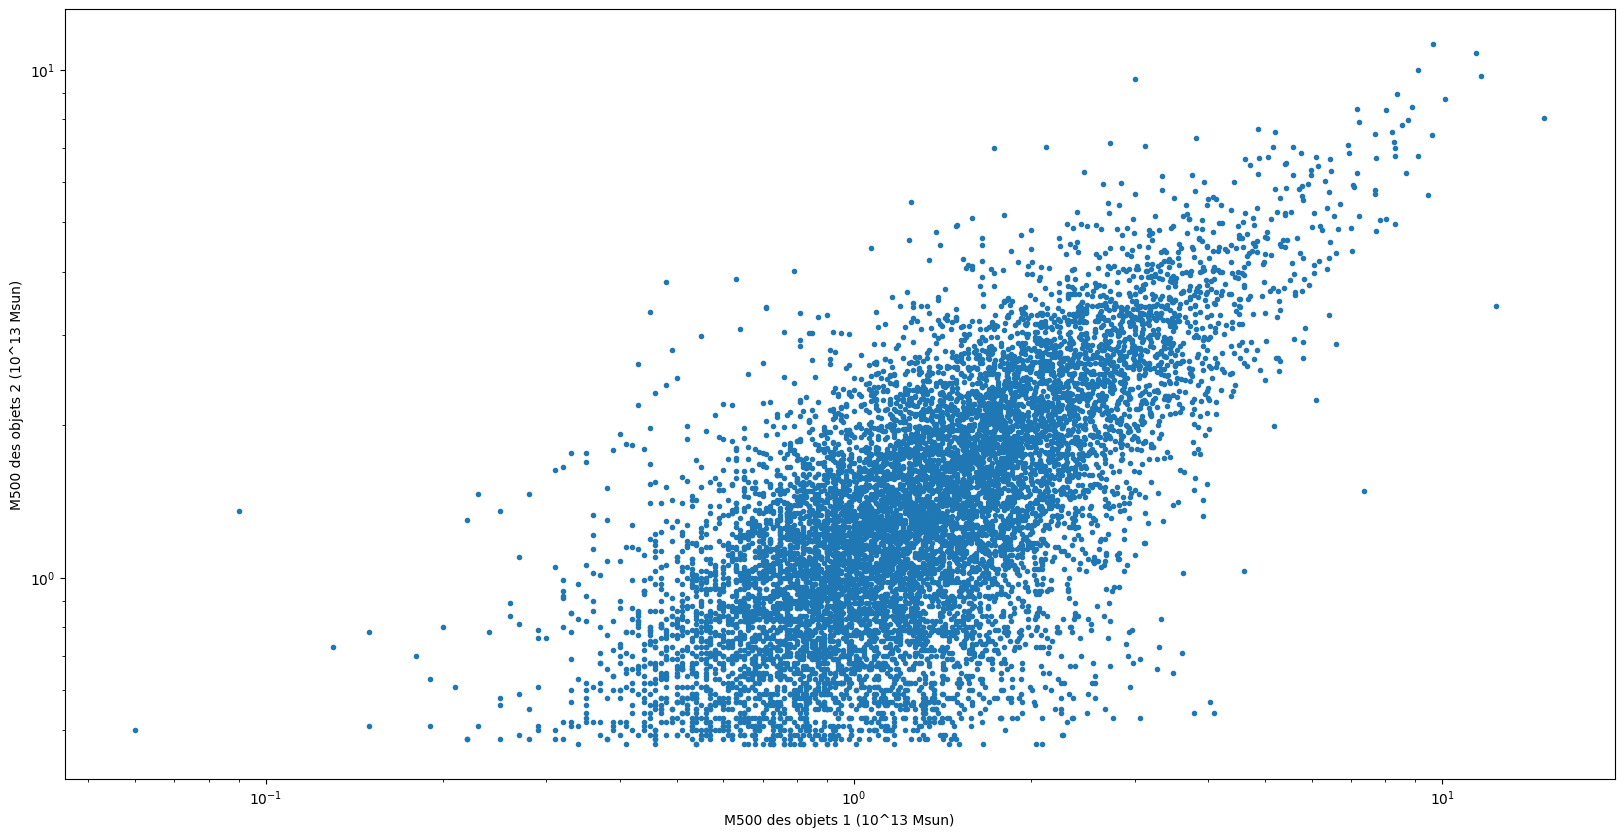

In [85]:
plt.figure(figsize=(20, 10))
plt.plot(M500_1, M_500_2, 'o', markersize=3)
plt.xlabel('M500 des objets 1 (10^13 Msun)')
plt.ylabel('M500 des objets 2 (10^13 Msun)')
plt.xscale('log')
plt.yscale('log')
output_path = os.path.join(folder_plots, "M500_2_vs_M500_1.png")
plt.savefig(output_path, dpi=300)

In [86]:
table_2_associated_3D

,__indexes,glon,glat,_RAJ2000,_DEJ2000,ID,n_Name,Name,RAJ2000,DEJ2000,...,M500,Ngal,Gamma,e_Gamma,imag_,Cat,recno,z,id_asso_1,id_associations
30817,30817,110.942327,-62.571973,7.36844,-0.21263,30818,,J002928.4-001245,7.36844,-0.21263,...,1.55,31,-0.44,0.13,1,WHL,30818,0.0610,1735,"[1735, 30817]"
44959,44959,115.236415,-72.031330,10.46032,-9.30312,44960,,J004150.5-091811,10.46032,-9.30312,...,2.47,52,-0.45,0.10,1,WHL,44960,0.0554,2644,"[2644, 44959]"
50525,50525,119.209892,-69.867178,11.56945,-7.03273,50526,,J004616.7-070158,11.56945,-7.03273,...,0.61,11,0.00,0.00,1,AMF,50526,0.0545,2979,"[2979, 50525]"
974715,974715,121.391442,-61.509474,12.12451,1.35348,974716,,J004829.9+012113,12.12451,1.35348,...,1.70,25,0.00,0.00,2,AMF,974716,0.0633,3149,"[3149, 974715]"
975336,975336,121.721062,-67.081331,12.38669,-4.21403,975337,,J004932.8-041251,12.38669,-4.21403,...,0.53,12,0.00,0.00,2,AMF,975337,0.0535,3210,"[3210, 975336]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93351,93351,137.422275,-60.846471,19.86251,1.23475,93352,,J011927.0+011405,19.86251,1.23475,...,2.16,22,0.00,0.00,1,WHL,93352,0.6130,5372,"[5372, 93351]"
170566,170566,168.130721,-58.291958,34.79555,-3.34275,170567,WH-,J021910.9-032034,34.79555,-3.34275,...,1.13,9,0.00,0.00,1,,170567,0.6107,8943,"[8943, 170566]"
1534916,1534916,72.878502,-42.451872,338.15344,6.53766,1534917,,J223236.8+063216,338.15344,6.53766,...,5.22,56,-2.16,0.12,2,WHL,1534917,0.6065,14399,"[14399, 1534916]"
895466,895466,68.703513,-52.565924,343.27548,-2.62759,895467,,J225306.1-023739,343.27548,-2.62759,...,3.52,33,0.12,0.05,1,WHL,895467,0.6103,15465,"[15465, 895466]"


(array([ 206.,  706., 1124., 1538., 1687., 1772., 1536., 1203.,  514.,
          62.]),
 array([0.0426 , 0.10056, 0.15852, 0.21648, 0.27444, 0.3324 , 0.39036,
        0.44832, 0.50628, 0.56424, 0.6222 ]),
 <BarContainer object of 10 artists>)

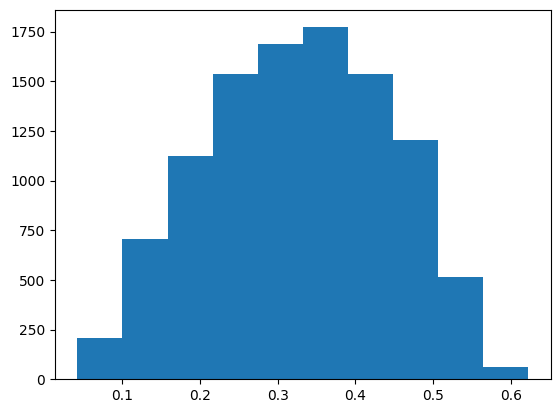

In [87]:
plt.hist(table_2_associated_3D['zCl'])

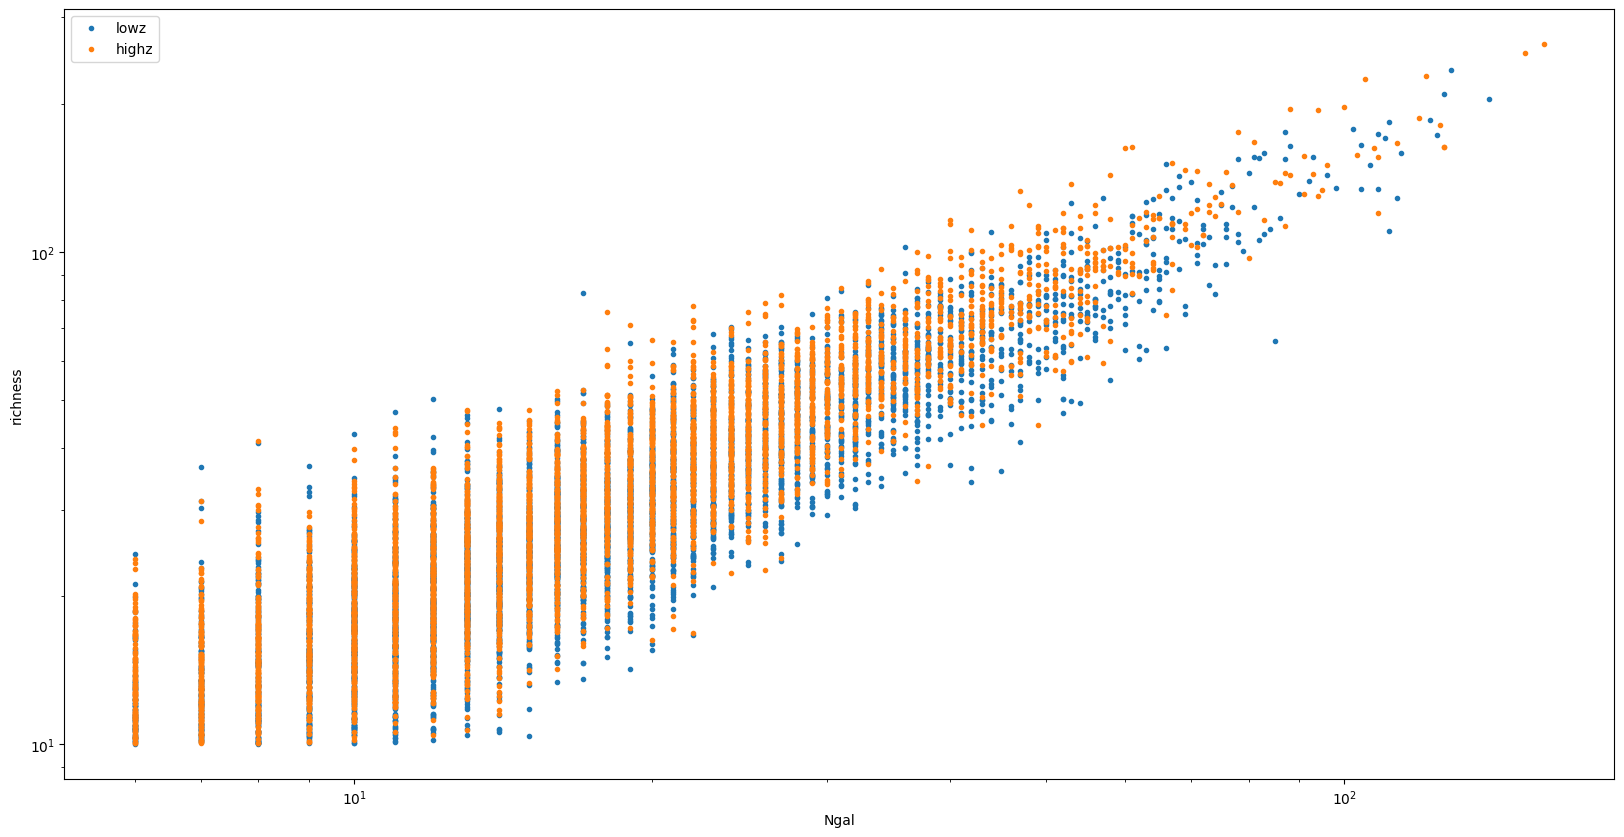

In [88]:
table_2_associated_3D_low_z = table_2_associated_3D[table_2_associated_3D['zCl']<0.35]
table_2_associated_3D_high_z = table_2_associated_3D[table_2_associated_3D['zCl']>0.35]


N_gal_low_z = table_2_associated_3D_low_z['Ngal']
richness_low_z = table_2_associated_3D_low_z['lam500']

N_gal_high_z = table_2_associated_3D_high_z['Ngal']
richness_high_z = table_2_associated_3D_high_z['lam500']


plt.figure(figsize=(20, 10))
plt.plot(N_gal_low_z, richness_low_z, 'o', markersize=3,label='lowz')
plt.plot(N_gal_high_z, richness_high_z, 'o', markersize=3,label='highz')
plt.xlabel('Ngal')
plt.ylabel('richness')
plt.xscale('log')
plt.yscale('log')
plt.legend()

'output_path = os.path.join(folder_plots, "histogramme_diff_M500.png")\nplt.savefig(output_path, dpi=300)'

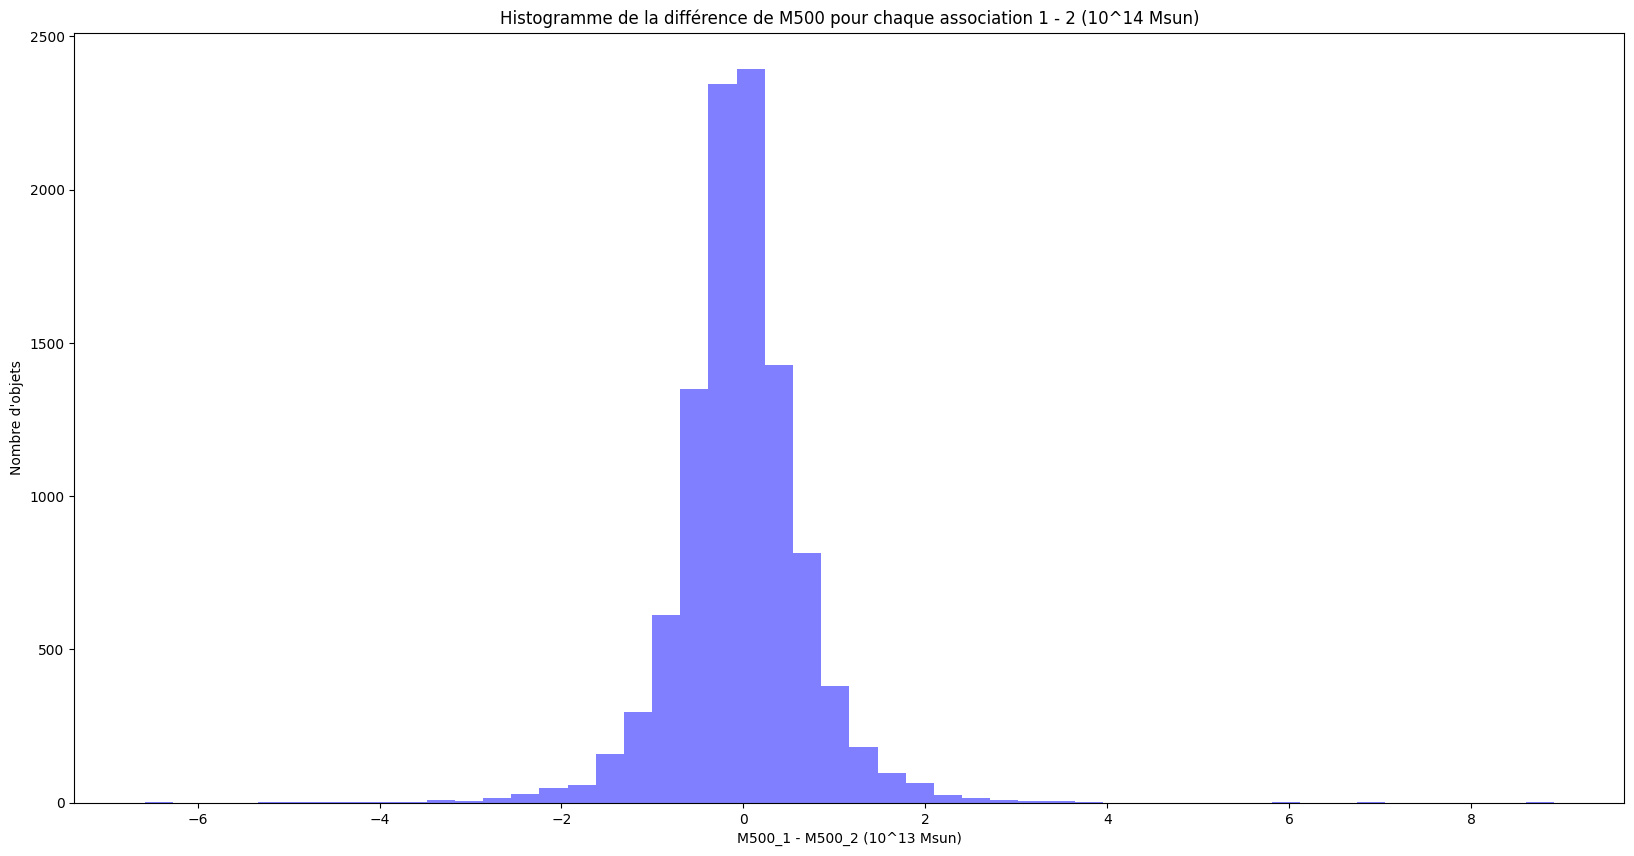

In [89]:
# Histogramme M500_1 - M500_2
diff_mass = M500_1 - M_500_2

plt.figure(figsize=(20, 10))
plt.hist(diff_mass, bins=50, color='blue', alpha=0.5)
plt.xlabel('M500_1 - M500_2 (10^13 Msun)')
plt.ylabel('Nombre d\'objets')
plt.title('Histogramme de la différence de M500 pour chaque association 1 - 2 (10^14 Msun)')

'''output_path = os.path.join(folder_plots, "histogramme_diff_M500.png")
plt.savefig(output_path, dpi=300)'''

'output_path = os.path.join(folder_plots, "histogramme_diff_M500_normalisée.png")\nplt.savefig(output_path, dpi=300)'

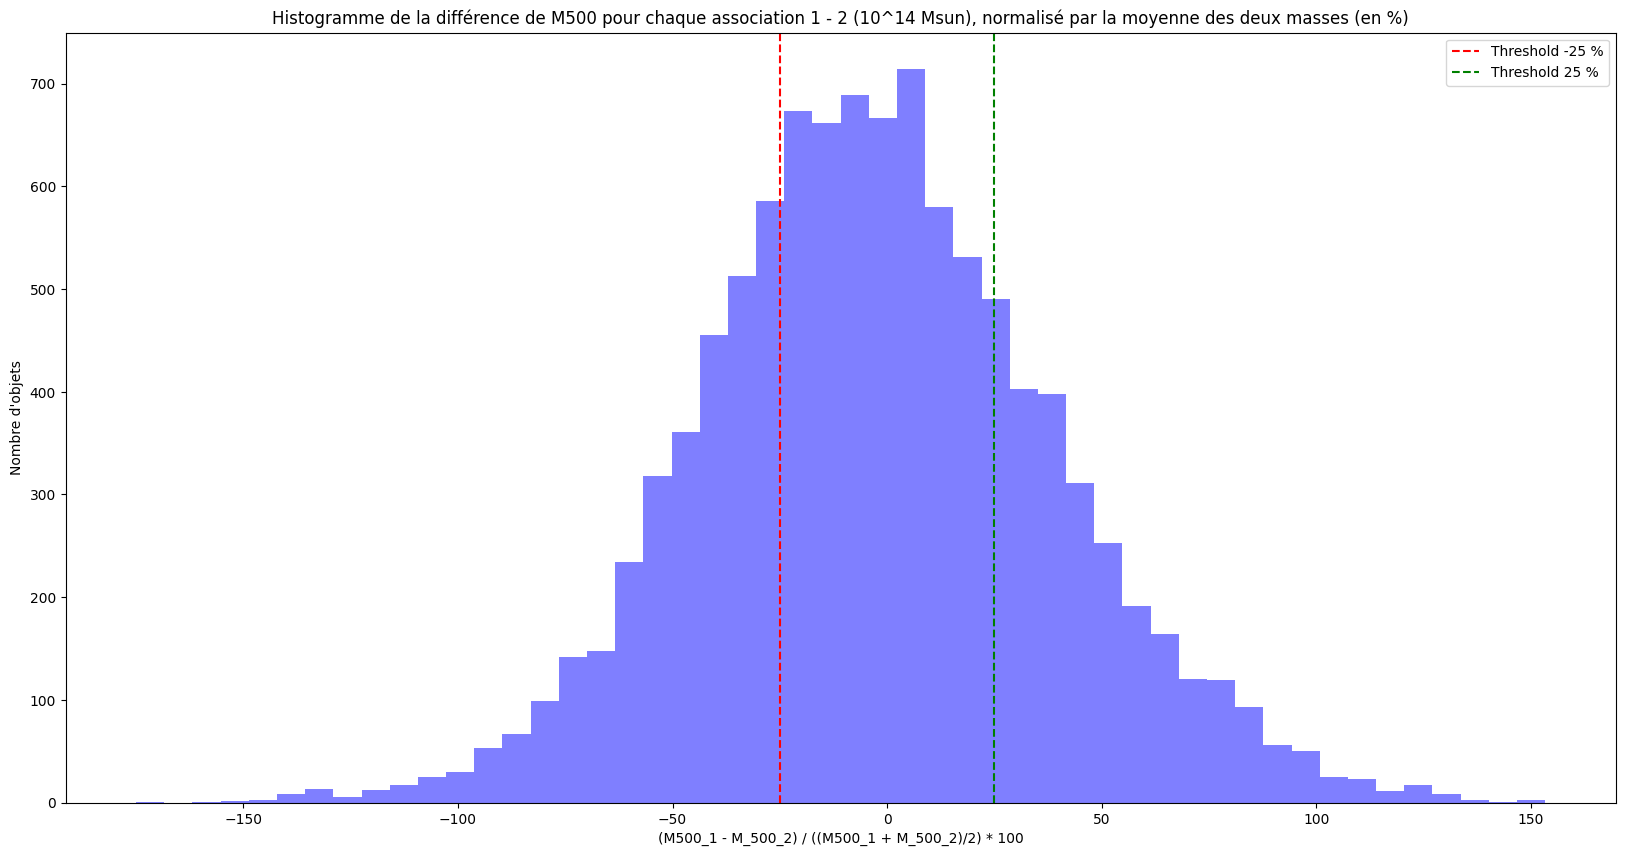

In [90]:
diff_mass_normalisée = ((M500_1 - M_500_2) / ((M500_1 + M_500_2)/2))*100


plt.figure(figsize=(20, 10))
plt.hist(diff_mass_normalisée , bins=50, color='blue', alpha=0.5)

# Add thresholds
threshold1 = -25  # Example threshold
threshold2 = 25   # Example threshold
plt.axvline(x=threshold1, color='red', linestyle='--', label=f'Threshold {threshold1} %')
plt.axvline(x=threshold2, color='green', linestyle='--', label=f'Threshold {threshold2} %')

plt.xlabel('(M500_1 - M_500_2) / ((M500_1 + M_500_2)/2) * 100')
plt.ylabel('Nombre d\'objets')
plt.title('Histogramme de la différence de M500 pour chaque association 1 - 2 (10^14 Msun), normalisé par la moyenne des deux masses (en %)')

plt.legend()

'''output_path = os.path.join(folder_plots, "histogramme_diff_M500_normalisée.png")
plt.savefig(output_path, dpi=300)'''

In [91]:
suspect_associations_mass_indexes
table_1_crossed_3D_suspect = table_1_crossed_3D.loc[suspect_associations_mass_indexes_X] # On récupère les objets X des associations suspectes
table_2_associated_3D_suspect = table_2_associated_3D.loc[suspect_associations_mass_indexes_2] # On récupère les objets 2 des associations suspectes

NameError: name 'suspect_associations_mass_indexes' is not defined

In [ ]:
table_1_crossed_3D_suspect

NameError: name 'table_1_crossed_3D_suspect' is not defined

In [92]:
table_2_associated_3D_suspect

NameError: name 'table_2_associated_3D_suspect' is not defined